# BigMart Sales Prediction

## Advanced End-to-End Machine Learning Project

### Objective
Predict `Item_Outlet_Sales` using product and outlet information.

### Machine Learning Type
Supervised Learning - Regression

### Target Variable
`Item_Outlet_Sales`

### Project Workflow
Data Loading → Data Validation → EDA → Cleaning → Feature Engineering
→ Model Comparison → Hyperparameter Optimization → Ensemble
→ Explainability → Final Model → Deployment

In [1]:
import os

os.environ["LOKY_MAX_CPU_COUNT"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

print("CPU parallelism limited to 1 worker for Windows stability.")

CPU parallelism limited to 1 worker for Windows stability.


In [2]:
import os
import warnings
import random

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

SEED = 42

np.random.seed(SEED)
random.seed(SEED)

print("Environment initialized successfully.")

Environment initialized successfully.


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

In [4]:
from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_val_score
)

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    ElasticNet
)

from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    HistGradientBoostingRegressor
)

In [5]:
%pip install lightgbm catboost xgboost

Note: you may need to restart the kernel to use updated packages.


In [6]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

print("Advanced ML libraries loaded.")

Advanced ML libraries loaded.


In [7]:
DATA_DIR = "../data"
MODEL_DIR = "../models"
REPORT_DIR = "../reports"

TRAIN_PATH = os.path.join(DATA_DIR, "Train.csv")
TEST_PATH = os.path.join(DATA_DIR, "Test.csv")

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

print("Train path:", TRAIN_PATH)
print("Test path :", TEST_PATH)

Train path: ../data\Train.csv
Test path : ../data\Test.csv


In [8]:
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)

print("Train shape:", train.shape)
print("Test shape :", test.shape)

Train shape: (8523, 12)
Test shape : (5681, 11)


In [9]:
train_raw = train.copy()
test_raw = test.copy()

print("Raw datasets copied.")

Raw datasets copied.


In [10]:
train.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [11]:
train.tail()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834
8519,FDS36,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,2002,NaN,Tier 2,Supermarket Type1,549.2850
8520,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,2004,Small,Tier 2,Supermarket Type1,1193.1136
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,2009,Medium,Tier 3,Supermarket Type2,1845.5976
8522,DRG01,14.800,Low Fat,0.044878,Soft Drinks,75.4670,OUT046,1997,Small,Tier 1,Supermarket Type1,765.6700


In [12]:
train.sample(10, random_state=SEED)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
7503,FDI28,14.300,Low Fat,0.026300,Frozen Foods,79.4302,OUT013,1987,High,Tier 3,Supermarket Type1,1743.0644
2957,NCM17,7.930,Low Fat,0.071136,Health and Hygiene,42.7086,OUT046,1997,Small,Tier 1,Supermarket Type1,356.8688
7031,FDC14,14.500,Regular,0.041313,Canned,42.0454,OUT049,1999,Medium,Tier 1,Supermarket Type1,377.5086
1084,DRC36,NaN,Regular,0.044767,Soft Drinks,173.7054,OUT027,1985,Medium,Tier 3,Supermarket Type3,5778.4782
856,FDS27,10.195,Regular,0.012456,Meat,197.5110,OUT035,2004,Small,Tier 2,Supermarket Type1,2356.9320
4304,DRK12,9.500,Low Fat,0.041951,Soft Drinks,32.4900,OUT049,1999,Medium,Tier 1,Supermarket Type1,865.5400
2132,FDO25,NaN,Low Fat,0.126832,Canned,209.0270,OUT027,1985,Medium,Tier 3,Supermarket Type3,4613.9940
1385,FDB58,10.500,Regular,0.013551,Snack Foods,142.0154,OUT018,2009,Medium,Tier 3,Supermarket Type2,2410.8618
5239,FDY48,14.000,Low Fat,0.023832,Baking Goods,103.1332,OUT018,2009,Medium,Tier 3,Supermarket Type2,1948.1308
6516,NCP42,8.510,Low Fat,0.016176,Household,192.1478,OUT018,2009,Medium,Tier 3,Supermarket Type2,1937.4780


In [13]:
print("Train Shape:", train.shape)
print("Test Shape :", test.shape)

print("\nTrain Columns:")
for col in train.columns:
    print("-", col)

Train Shape: (8523, 12)
Test Shape : (5681, 11)

Train Columns:
- Item_Identifier
- Item_Weight
- Item_Fat_Content
- Item_Visibility
- Item_Type
- Item_MRP
- Outlet_Identifier
- Outlet_Establishment_Year
- Outlet_Size
- Outlet_Location_Type
- Outlet_Type
- Item_Outlet_Sales


In [14]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [15]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5681 entries, 0 to 5680
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            5681 non-null   object 
 1   Item_Weight                4705 non-null   float64
 2   Item_Fat_Content           5681 non-null   object 
 3   Item_Visibility            5681 non-null   float64
 4   Item_Type                  5681 non-null   object 
 5   Item_MRP                   5681 non-null   float64
 6   Outlet_Identifier          5681 non-null   object 
 7   Outlet_Establishment_Year  5681 non-null   int64  
 8   Outlet_Size                4075 non-null   object 
 9   Outlet_Location_Type       5681 non-null   object 
 10  Outlet_Type                5681 non-null   object 
dtypes: float64(3), int64(1), object(7)
memory usage: 488.3+ KB


In [16]:
train.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Item_Identifier,8523,1559,FDW13,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Item_Weight,7060.0,NaN,NaN,NaN,12.857645,4.643456,4.555,8.77375,12.6,16.85,21.35
Item_Fat_Content,8523,5,Low Fat,5089,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Item_Visibility,8523.0,NaN,NaN,NaN,0.066132,0.051598,0.0,0.026989,0.053931,0.094585,0.328391
Item_Type,8523,16,Fruits and Vegetables,1232,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Item_MRP,8523.0,NaN,NaN,NaN,140.992782,62.275067,31.29,93.8265,143.0128,185.6437,266.8884
Outlet_Identifier,8523,10,OUT027,935,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Outlet_Establishment_Year,8523.0,NaN,NaN,NaN,1997.831867,8.37176,1985.0,1987.0,1999.0,2004.0,2009.0
Outlet_Size,6113,3,Medium,2793,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Outlet_Location_Type,8523,3,Tier 3,3350,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
missing = (
    train.isnull()
         .sum()
         .sort_values(ascending=False)
)

missing_df = pd.DataFrame({
    "Missing_Count": missing,
    "Missing_Percentage": (
        missing / len(train) * 100
    ).round(2)
})

missing_df

,Missing_Count,Missing_Percentage
Outlet_Size,2410,28.28
Item_Weight,1463,17.17
Item_Fat_Content,0,0.00
Item_Identifier,0,0.00
Item_Visibility,0,0.00
Item_Type,0,0.00
Outlet_Identifier,0,0.00
Item_MRP,0,0.00
Outlet_Establishment_Year,0,0.00
Outlet_Location_Type,0,0.00


In [18]:
print("Duplicate rows:", train.duplicated().sum())
print("Duplicate rows in test:", test.duplicated().sum())

Duplicate rows: 0
Duplicate rows in test: 0


In [19]:
for col in train.columns:
    print(f"\n{'='*60}")
    print(col)
    print("Unique values:", train[col].nunique())
    print(train[col].unique()[:20])


Item_Identifier
Unique values: 1559
['FDA15' 'DRC01' 'FDN15' 'FDX07' 'NCD19' 'FDP36' 'FDO10' 'FDP10' 'FDH17'
 'FDU28' 'FDY07' 'FDA03' 'FDX32' 'FDS46' 'FDF32' 'FDP49' 'NCB42' 'DRI11'
 'FDU02' 'FDN22']

Item_Weight
Unique values: 415
[ 9.3    5.92  17.5   19.2    8.93  10.395 13.65     nan 16.2   11.8
 18.5   15.1   17.6   16.35   9.    13.35  18.85  14.6   13.85  13.   ]

Item_Fat_Content
Unique values: 5
['Low Fat' 'Regular' 'low fat' 'LF' 'reg']

Item_Visibility
Unique values: 7880
[0.0160473  0.01927822 0.01676007 0.         0.01274109 0.12746986
 0.01668711 0.09444959 0.04546377 0.1000135  0.04725733 0.0680243
 0.06908896 0.00859605 0.06919638 0.03423768 0.10249212 0.13819028
 0.03539992 0.02569813]

Item_Type
Unique values: 16
['Dairy' 'Soft Drinks' 'Meat' 'Fruits and Vegetables' 'Household'
 'Baking Goods' 'Snack Foods' 'Frozen Foods' 'Breakfast'
 'Health and Hygiene' 'Hard Drinks' 'Canned' 'Breads' 'Starchy Foods'
 'Others' 'Seafood']

Item_MRP
Unique values: 5938
[249.8092  48.

In [20]:
TARGET = "Item_Outlet_Sales"

X = train.drop(columns=[TARGET])
y = train[TARGET]

print("Feature shape:", X.shape)
print("Target shape :", y.shape)

Feature shape: (8523, 11)
Target shape : (8523,)


In [21]:
print(y.describe())

count     8523.000000
mean      2181.288914
std       1706.499616
min         33.290000
25%        834.247400
50%       1794.331000
75%       3101.296400
max      13086.964800
Name: Item_Outlet_Sales, dtype: float64


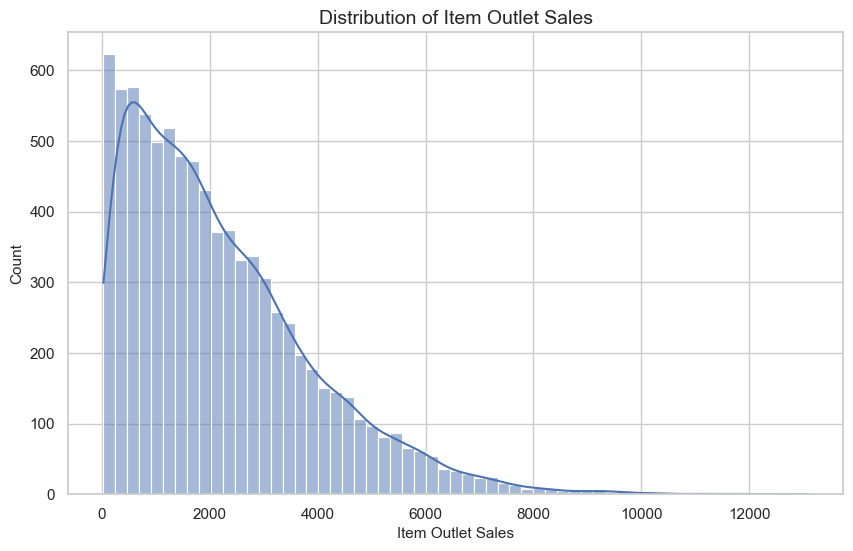

In [22]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    y,
    kde=True,
    ax=ax
)

ax.set_title("Distribution of Item Outlet Sales")
ax.set_xlabel("Item Outlet Sales")

plt.show()

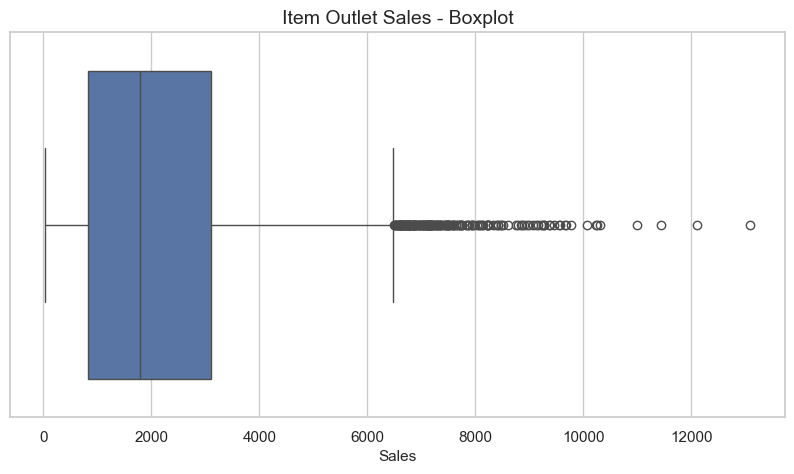

In [23]:
plt.figure(figsize=(10, 5))

sns.boxplot(x=y)

plt.title("Item Outlet Sales - Boxplot")
plt.xlabel("Sales")

plt.show()

In [24]:
numeric_cols = train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

numeric_cols

['Item_Weight',
 'Item_Visibility',
 'Item_MRP',
 'Outlet_Establishment_Year',
 'Item_Outlet_Sales']

In [25]:
numeric_features = [
    col for col in numeric_cols
    if col != TARGET
]

numeric_features

['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Establishment_Year']

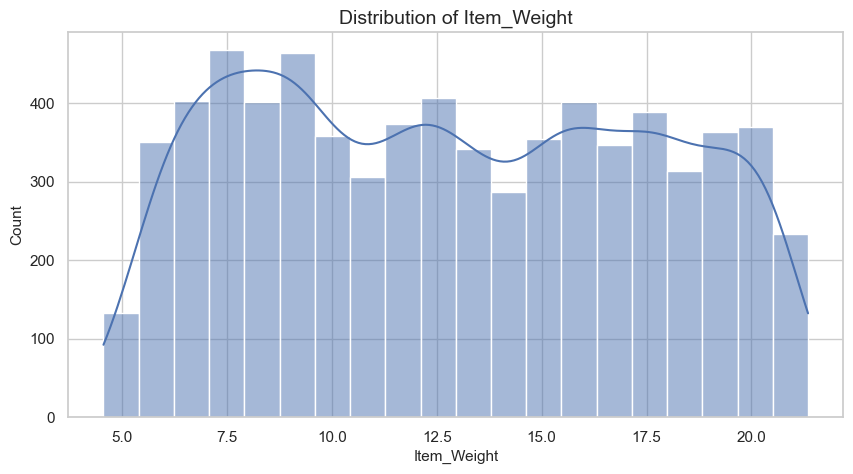

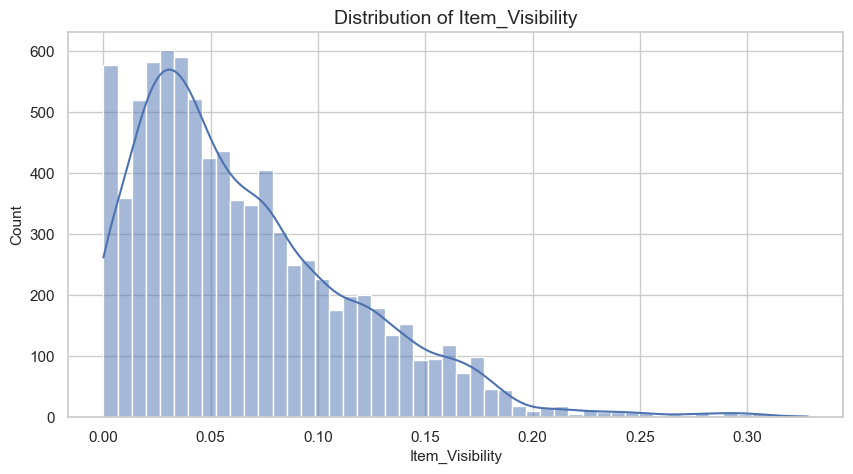

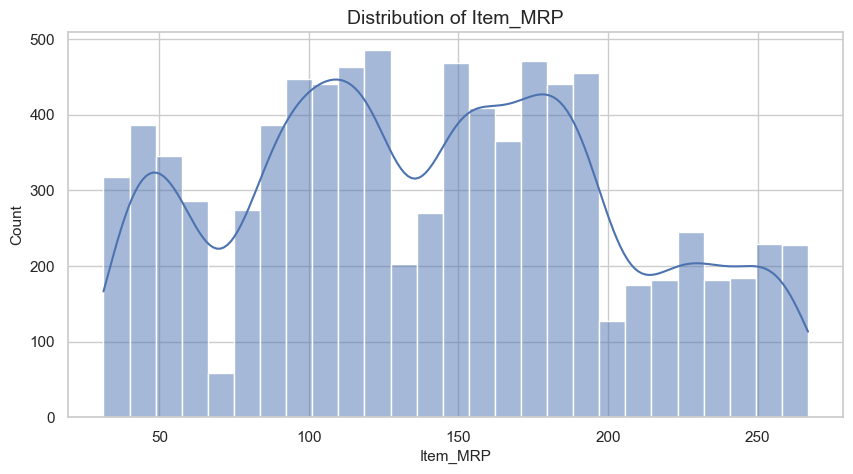

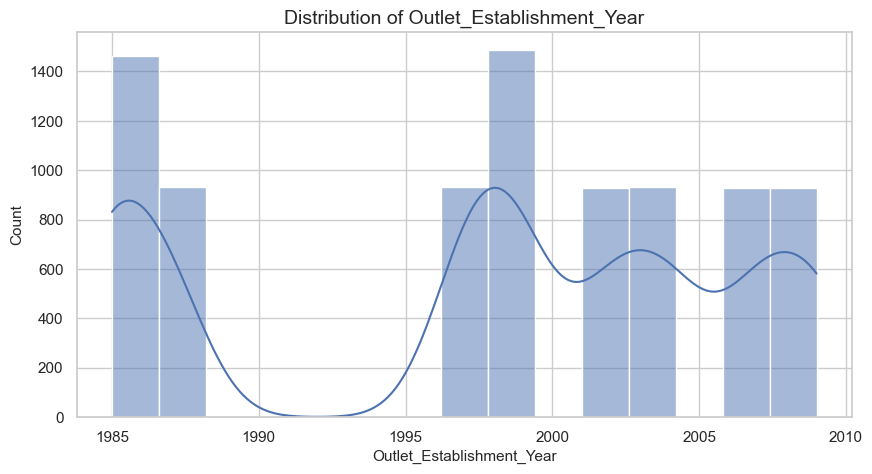

In [26]:
for col in numeric_features:

    plt.figure(figsize=(10, 5))

    sns.histplot(
        train[col],
        kde=True
    )

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)

    plt.show()

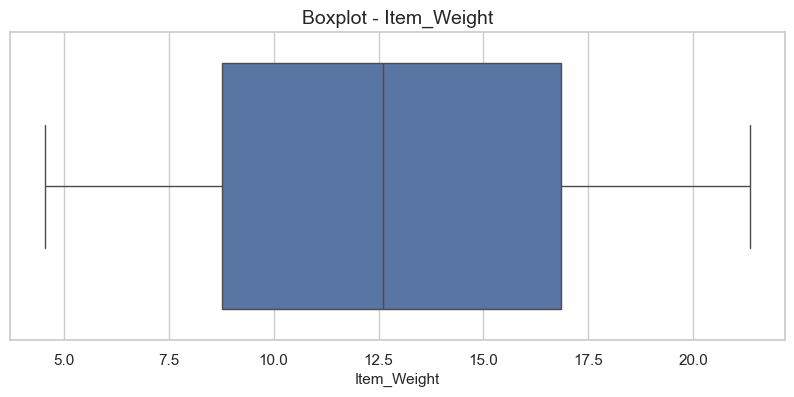

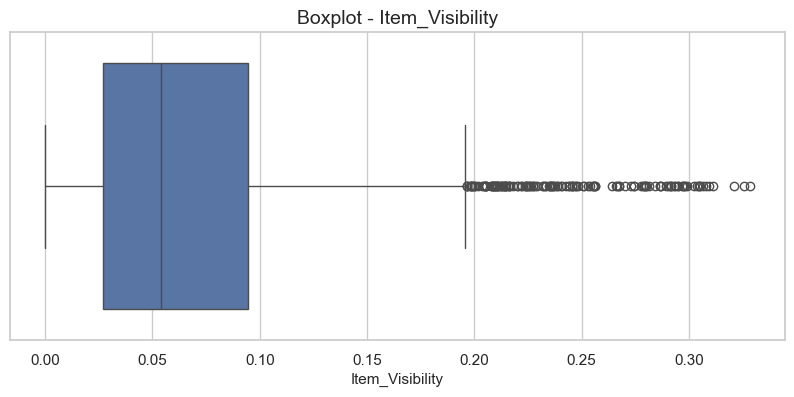

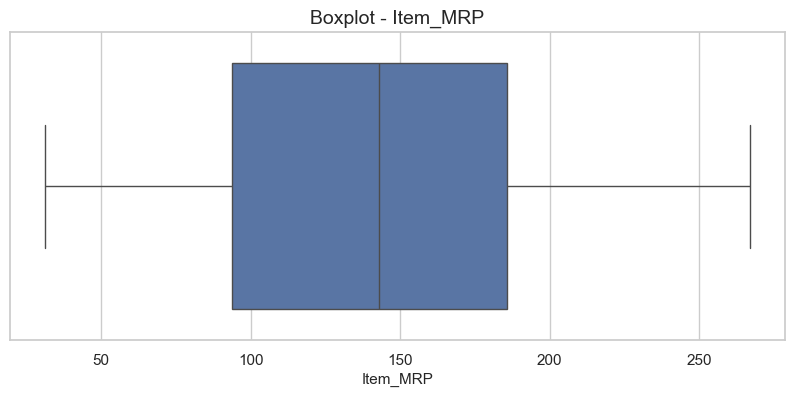

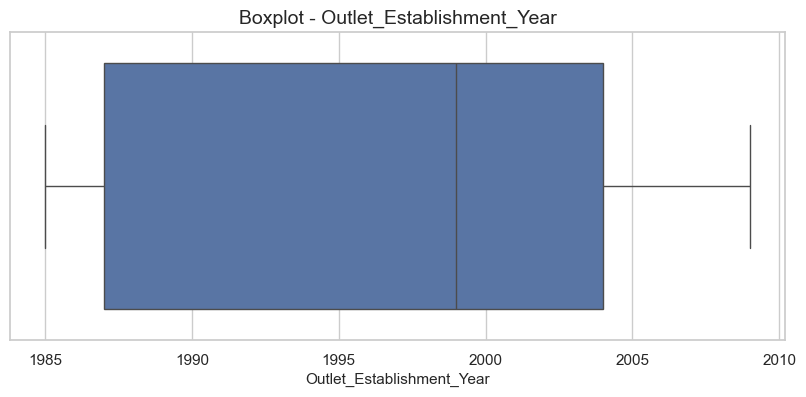

In [27]:
for col in numeric_features:

    plt.figure(figsize=(10, 4))

    sns.boxplot(
        x=train[col]
    )

    plt.title(f"Boxplot - {col}")
    plt.show()

In [28]:
categorical_cols = train.select_dtypes(
    include=["object"]
).columns.tolist()

categorical_cols

['Item_Identifier',
 'Item_Fat_Content',
 'Item_Type',
 'Outlet_Identifier',
 'Outlet_Size',
 'Outlet_Location_Type',
 'Outlet_Type']

In [29]:
for col in categorical_cols:

    print(f"\n{'='*60}")
    print(f"{col}")
    print(train[col].value_counts(dropna=False))


Item_Identifier
Item_Identifier
FDW13    10
FDG33    10
FDX31     9
FDT07     9
NCY18     9
         ..
FDO33     1
FDK57     1
FDT35     1
FDN52     1
FDE52     1
Name: count, Length: 1559, dtype: int64

Item_Fat_Content
Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64

Item_Type
Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64

Outlet_Identifier
Outlet_Identifier
OUT027    935
OUT013    932
OUT035    930
OUT049    930
OUT046    930
OUT045    929
OUT018

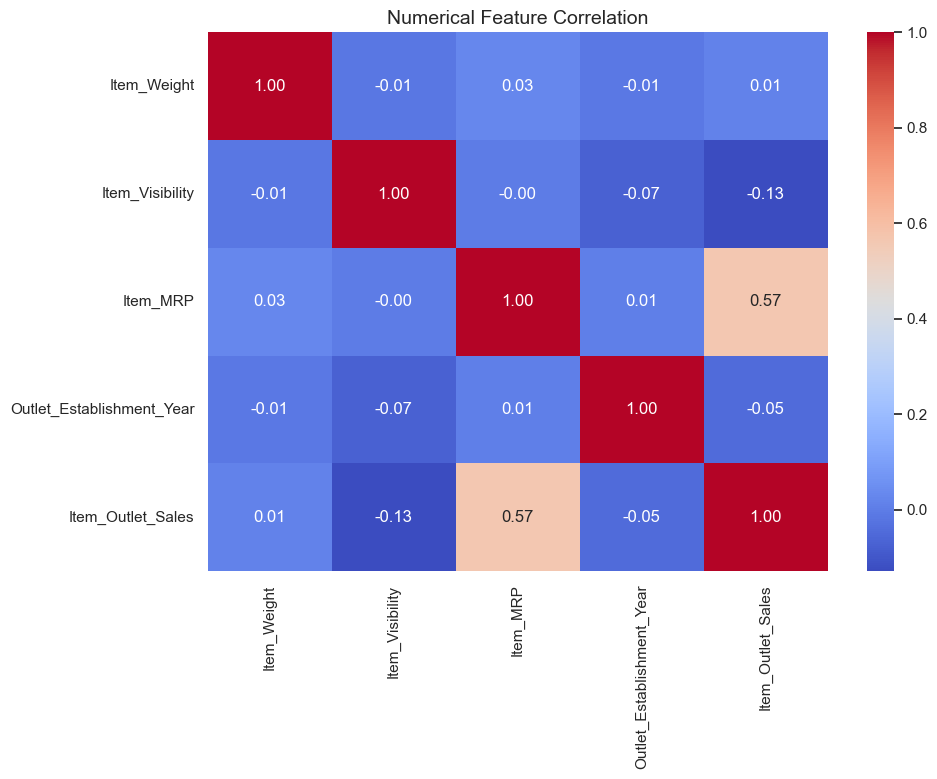

In [30]:
corr = train[numeric_cols].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Numerical Feature Correlation")

plt.show()

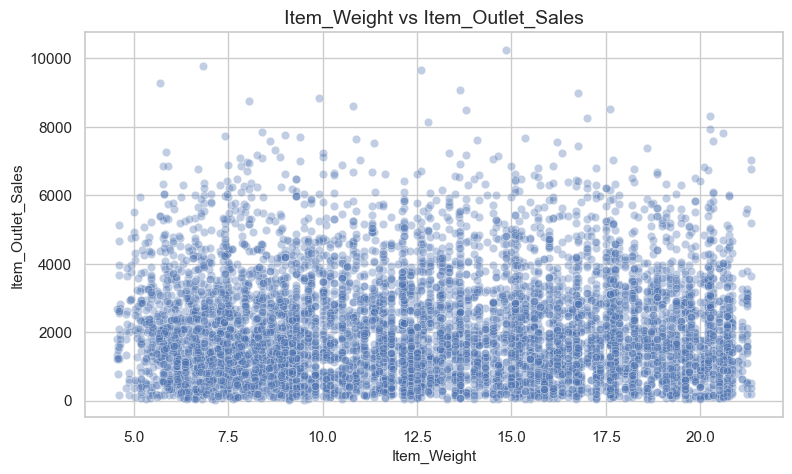

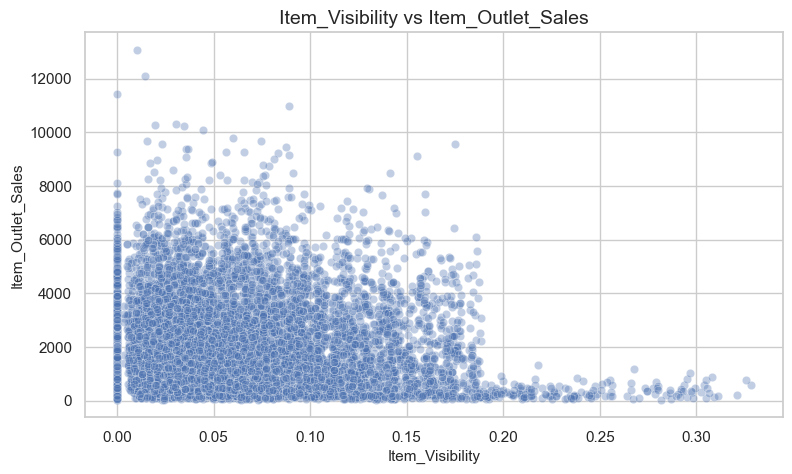

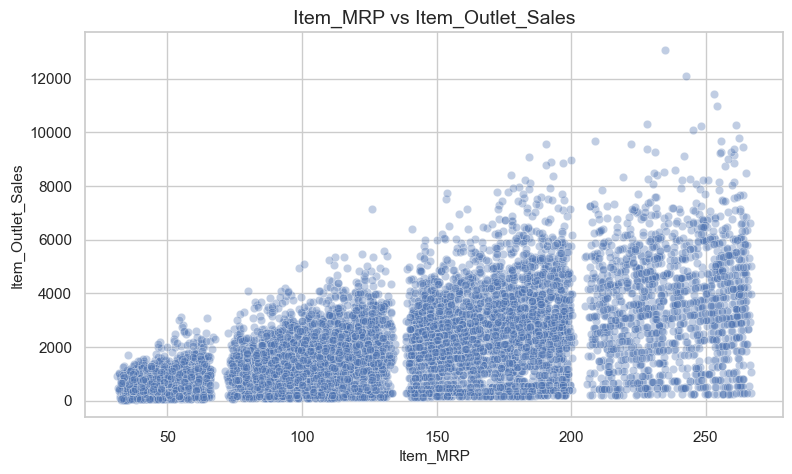

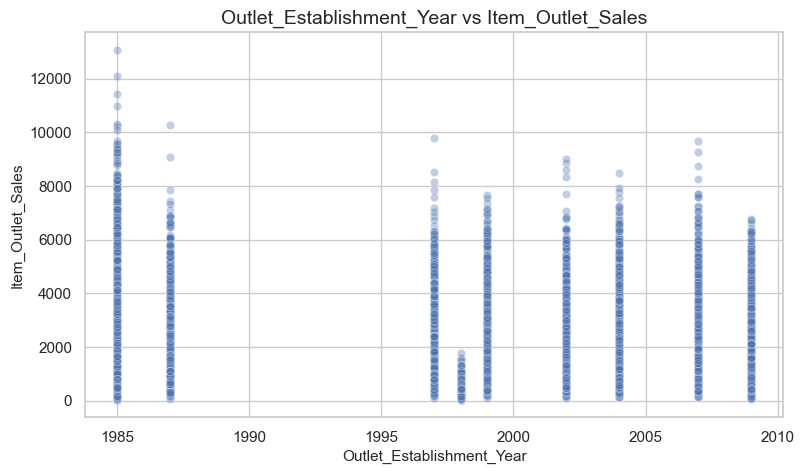

In [31]:
for col in numeric_features:

    plt.figure(figsize=(9, 5))

    sns.scatterplot(
        data=train,
        x=col,
        y=TARGET,
        alpha=0.35
    )

    plt.title(f"{col} vs {TARGET}")

    plt.show()

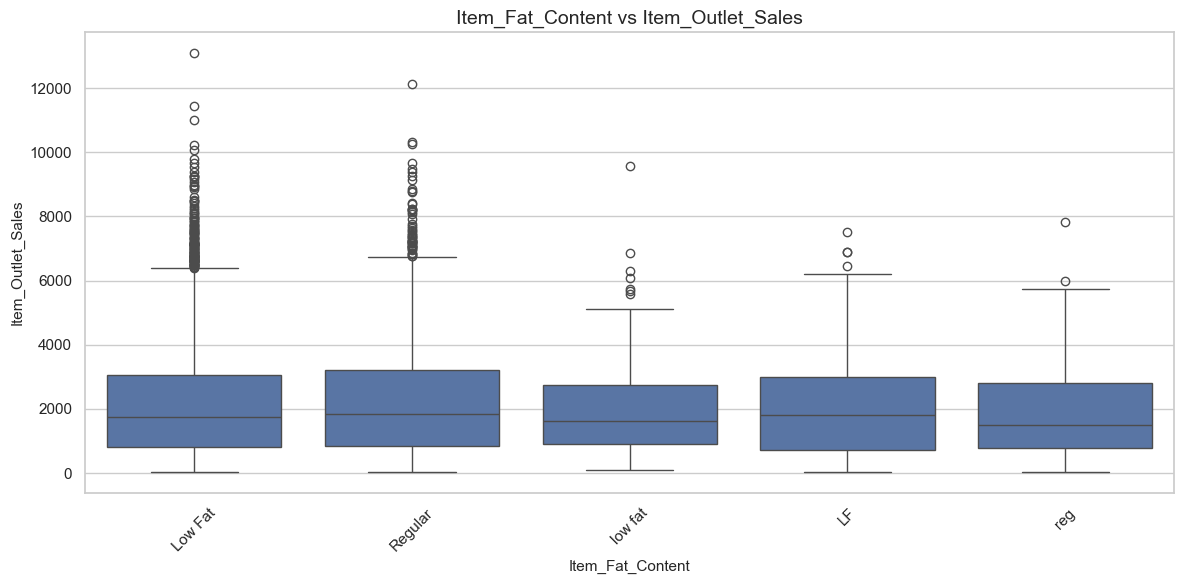

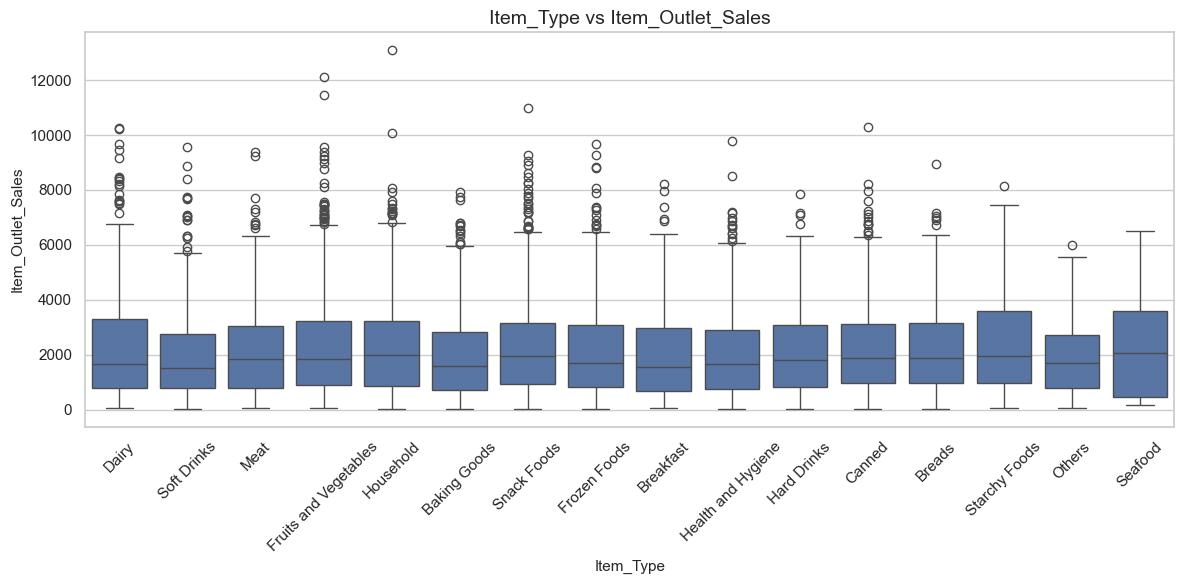

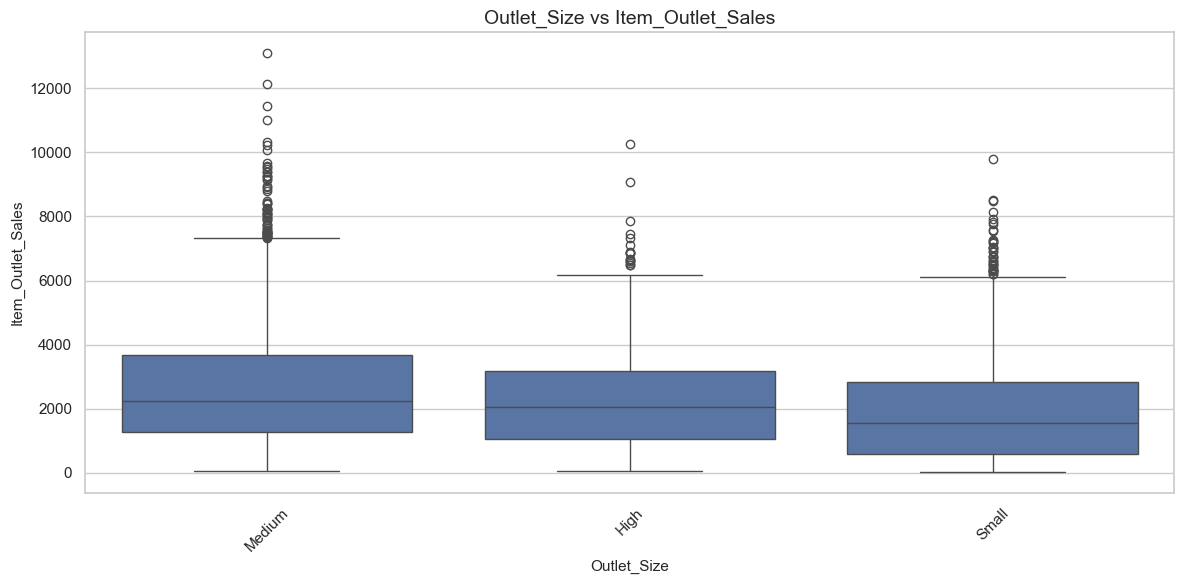

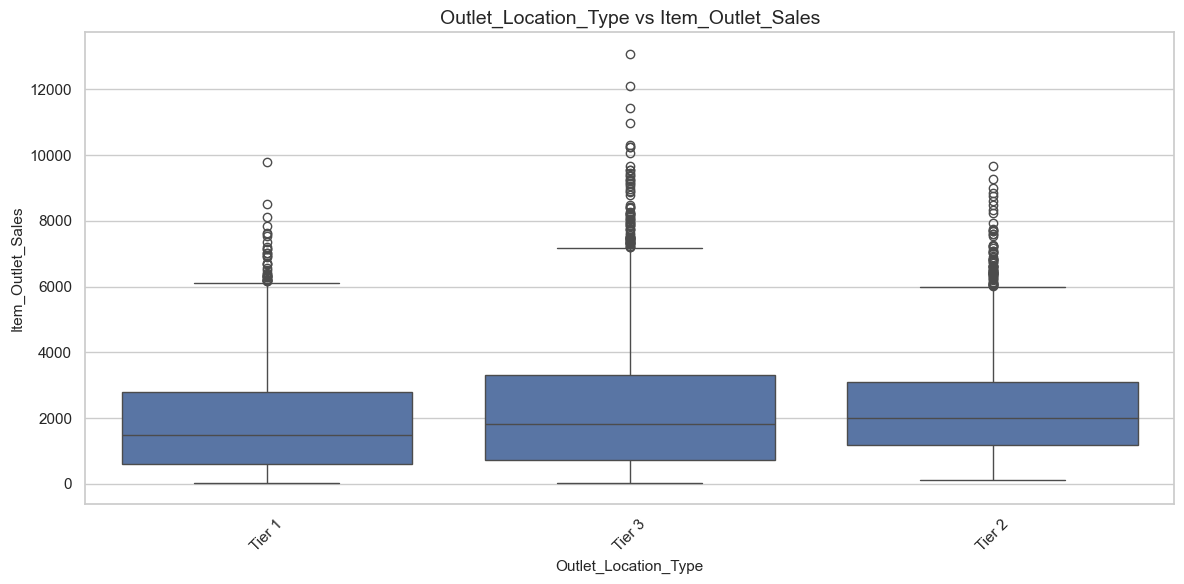

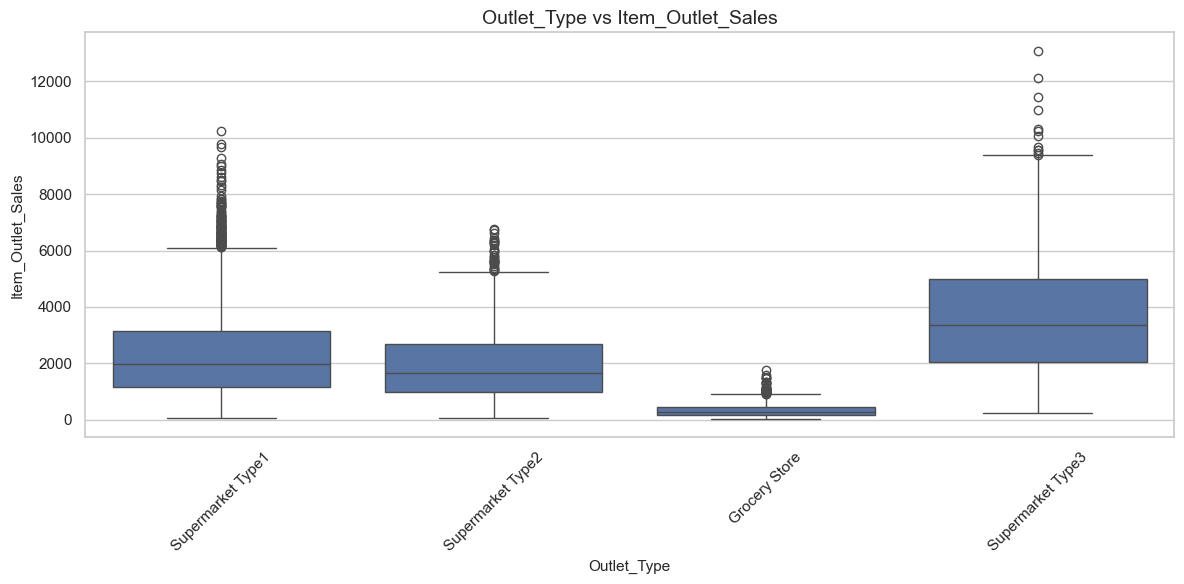

In [32]:
for col in [
    "Item_Fat_Content",
    "Item_Type",
    "Outlet_Size",
    "Outlet_Location_Type",
    "Outlet_Type"
]:

    plt.figure(figsize=(12, 6))

    sns.boxplot(
        data=train,
        x=col,
        y=TARGET
    )

    plt.xticks(rotation=45)
    plt.title(f"{col} vs {TARGET}")

    plt.tight_layout()
    plt.show()

## 🔎 Exploratory Data Analysis (EDA)

A detailed exploratory analysis is performed to understand the dataset, identify data-quality issues, discover patterns, and determine the factors that may influence `Item_Outlet_Sales`.

### EDA Checklist

- ✅ **Dataset Loading**  
  Load the raw BigMart dataset and verify that the required files and columns are available.

- ✅ **Dataset Structure**  
  Examine the shape, column names, data types, and overall structure of the dataset.

- ✅ **Data Quality & Consistency**  
  Check for inconsistent category names, invalid values, unexpected data types, and potential data-quality issues.

- ✅ **Missing Values**  
  Identify missing values, understand their distribution, and determine appropriate treatment strategies.

- ✅ **Duplicates**  
  Check for duplicate records to ensure data consistency and prevent unintended bias.

- ✅ **Unique Values**  
  Analyze unique values and category distributions to identify inconsistent or unexpected entries.

- ✅ **Target Analysis**  
  Analyze the distribution and statistical characteristics of `Item_Outlet_Sales`, the target variable.

- ✅ **Numerical Analysis**  
  Examine numerical features using descriptive statistics, distributions, skewness, and outlier analysis.

- ✅ **Categorical Analysis**  
  Analyze categorical features, category frequencies, and their potential influence on sales.

- ✅ **Correlation Analysis**  
  Evaluate relationships between numerical variables and identify features correlated with the target.

- ✅ **Relationship Analysis**  
  Explore feature–target relationships using visualizations to uncover important patterns and business insights.

### 🎯 EDA Objective

The goal of this analysis is to understand the underlying data patterns, detect potential data-quality problems, identify important predictive features, and establish a strong foundation for **feature engineering and machine learning model development**.

In [33]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED
)

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print("y_train:", y_train.shape)
print("y_valid:", y_valid.shape)

X_train: (6818, 11)
X_valid: (1705, 11)
y_train: (6818,)
y_valid: (1705,)


In [34]:
def clean_data(df):
    df = df.copy()

    # Standardize Item Fat Content
    if "Item_Fat_Content" in df.columns:
        df["Item_Fat_Content"] = (
            df["Item_Fat_Content"]
            .replace({
                "LF": "Low Fat",
                "low fat": "Low Fat",
                "reg": "Regular"
            })
        )

    return df

In [35]:
def feature_engineering(df):
    df = df.copy()

    df["Outlet_Age"] = (
        2026 - df["Outlet_Establishment_Year"]
    )

    df["Item_ID_Category"] = (
        df["Item_Identifier"]
        .astype(str)
        .str[:2]
    )

    df["Item_Visibility_Zero"] = (
        df["Item_Visibility"] == 0
    ).astype(int)


    df["Item_Visibility_Log"] = np.log1p(
        df["Item_Visibility"]
    )

   
    df["Item_MRP_Log"] = np.log1p(
        df["Item_MRP"]
    )

  
    df["MRP_Per_Weight"] = (
        df["Item_MRP"] /
        (df["Item_Weight"] + 1e-6)
    )

  
    df["Visibility_Per_MRP"] = (
        df["Item_Visibility"] /
        (df["Item_MRP"] + 1e-6)
    )

    
    df["MRP_Visibility"] = (
        df["Item_MRP"] *
        df["Item_Visibility"]
    )

    return df

In [36]:
X_train_fe = feature_engineering(
    clean_data(X_train)
)

X_valid_fe = feature_engineering(
    clean_data(X_valid)
)

test_fe = feature_engineering(
    clean_data(test)
)

print("Training features:", X_train_fe.shape)
print("Validation features:", X_valid_fe.shape)
print("Test features:", test_fe.shape)

Training features: (6818, 19)
Validation features: (1705, 19)
Test features: (5681, 19)


In [37]:
numeric_features = X_train_fe.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train_fe.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Establishment_Year', 'Outlet_Age', 'Item_Visibility_Zero', 'Item_Visibility_Log', 'Item_MRP_Log', 'MRP_Per_Weight', 'Visibility_Per_MRP', 'MRP_Visibility']

Categorical features:
['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Outlet_Identifier', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type', 'Item_ID_Category']


In [38]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

In [39]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [40]:
baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=200,
                random_state=SEED,
                n_jobs=-1
            )
        )
    ]
)

baseline_model.fit(
    X_train_fe,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Item_Weight',
                                                   'Item_Visibility',
                                                   'Item_MRP',
                                                   'Outlet_Establishment_Year',
                                                   'Outlet_Age',
                                                   'Item_Visibility_Zero',
                                                   'Item_Visibility_Log',
                                                   'Item_MRP_Log',
                                                   'MRP_Per_Weight',
                                                   'Visibility_Per_MRP',
                                                   'MRP_Visibility']),
                                                 ('cat',
                                                  Pipelin...ps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Item_Identifier',
                                                   'Item_Fat_Content',
                                                   'Item_Type',
                                                   'Outlet_Identifier',
                                                   'Outlet_Size',
                                                   'Outlet_Location_Type',
                                                   'Outlet_Type',
                                                   'Item_ID_Category'])])),
                ('model',
                 RandomForestRegressor(n_estimators=200, n_jobs=-1,
                                       random_state=42))])

In [41]:
def evaluate_regression(y_true, y_pred):

    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    percentage_error = (
        np.abs(y_true - y_pred) /
        np.maximum(np.abs(y_true), 1e-6)
    )

    within_10 = np.mean(
        percentage_error <= 0.10
    )

    within_20 = np.mean(
        percentage_error <= 0.20
    )

    return {
        "R2": r2,
        "MAE": mae,
        "RMSE": rmse,
        "Within_10pct": within_10,
        "Within_20pct": within_20
    }

In [42]:
baseline_pred = baseline_model.predict(
    X_valid_fe
)

baseline_metrics = evaluate_regression(
    y_valid,
    baseline_pred
)

baseline_metrics

{'R2': 0.562434747402232,
 'MAE': 761.2174244263929,
 'RMSE': np.float64(1090.5453950901442),
 'Within_10pct': np.float64(0.15425219941348975),
 'Within_20pct': np.float64(0.3096774193548387)}

In [43]:
results = []

results.append({
    "Model": "Random Forest Baseline",
    **baseline_metrics
})

pd.DataFrame(results)

,Model,R2,MAE,RMSE,Within_10pct,Within_20pct
0,Random Forest Baseline,0.562435,761.217424,1090.545395,0.154252,0.309677


In [44]:
def train_and_evaluate(model_name, model, X_train, X_valid, y_train, y_valid):
    """
    Train a regression model and evaluate it on the validation set.
    """

    print(f"\n{'=' * 70}")
    print(f"Training: {model_name}")
    print(f"{'=' * 70}")

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    valid_pred = model.predict(X_valid)

    train_metrics = evaluate_regression(
        y_train,
        train_pred
    )

    valid_metrics = evaluate_regression(
        y_valid,
        valid_pred
    )

    result = {
        "Model": model_name,

        "Train_R2": train_metrics["R2"],
        "Valid_R2": valid_metrics["R2"],

        "Train_MAE": train_metrics["MAE"],
        "Valid_MAE": valid_metrics["MAE"],

        "Train_RMSE": train_metrics["RMSE"],
        "Valid_RMSE": valid_metrics["RMSE"],

        "Valid_Within_10pct": valid_metrics["Within_10pct"],
        "Valid_Within_20pct": valid_metrics["Within_20pct"]
    }

    print(f"Train R²       : {result['Train_R2']:.4f}")
    print(f"Validation R²  : {result['Valid_R2']:.4f}")
    print(f"Validation MAE : {result['Valid_MAE']:.2f}")
    print(f"Validation RMSE: {result['Valid_RMSE']:.2f}")
    print(f"Within ±10%    : {result['Valid_Within_10pct']:.2%}")
    print(f"Within ±20%    : {result['Valid_Within_20pct']:.2%}")

    return model, result

In [45]:
extra_trees = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            ExtraTreesRegressor(
                n_estimators=300,
                random_state=SEED,
                n_jobs=-1
            )
        )
    ]
)

extra_trees, extra_trees_result = train_and_evaluate(
    "Extra Trees",
    extra_trees,
    X_train_fe,
    X_valid_fe,
    y_train,
    y_valid
)

results.append(extra_trees_result)


Training: Extra Trees
Train R²       : 1.0000
Validation R²  : 0.5230
Validation MAE : 791.39
Validation RMSE: 1138.63
Within ±10%    : 15.54%
Within ±20%    : 30.67%


In [46]:
hist_gradient = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            HistGradientBoostingRegressor(
                max_iter=500,
                learning_rate=0.05,
                max_leaf_nodes=31,
                l2_regularization=1.0,
                random_state=SEED
            )
        )
    ]
)

hist_gradient, hist_gradient_result = train_and_evaluate(
    "HistGradientBoosting",
    hist_gradient,
    X_train_fe,
    X_valid_fe,
    y_train,
    y_valid
)

results.append(hist_gradient_result)


Training: HistGradientBoosting
Train R²       : 0.8112
Validation R²  : 0.5645
Validation MAE : 752.84
Validation RMSE: 1087.95
Within ±10%    : 16.19%
Within ±20%    : 32.73%


In [47]:
xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            XGBRegressor(
                n_estimators=500,
                learning_rate=0.03,
                max_depth=4,
                min_child_weight=5,
                subsample=0.8,
                colsample_bytree=0.8,
                reg_alpha=0.1,
                reg_lambda=5.0,
                objective="reg:squarederror",
                random_state=SEED,
                n_jobs=-1
            )
        )
    ]
)

xgb_model, xgb_result = train_and_evaluate(
    "XGBoost",
    xgb_model,
    X_train_fe,
    X_valid_fe,
    y_train,
    y_valid
)

results.append(xgb_result)


Training: XGBoost
Train R²       : 0.6562
Validation R²  : 0.6089
Validation MAE : 719.67
Validation RMSE: 1031.07
Within ±10%    : 17.07%
Within ±20%    : 35.48%


In [48]:
lgbm_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LGBMRegressor(
                n_estimators=500,
                learning_rate=0.03,
                max_depth=5,
                num_leaves=31,
                min_child_samples=30,
                subsample=0.8,
                colsample_bytree=0.8,
                reg_alpha=0.1,
                reg_lambda=5.0,
                random_state=SEED,
                n_jobs=-1,
                verbosity=-1
            )
        )
    ]
)

lgbm_model, lgbm_result = train_and_evaluate(
    "LightGBM",
    lgbm_model,
    X_train_fe,
    X_valid_fe,
    y_train,
    y_valid
)

results.append(lgbm_result)


Training: LightGBM
Train R²       : 0.6757
Validation R²  : 0.6036
Validation MAE : 721.12
Validation RMSE: 1037.94
Within ±10%    : 16.30%
Within ±20%    : 35.13%


In [49]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Valid_R2",
    ascending=False
).reset_index(drop=True)

results_df

,Model,R2,MAE,RMSE,Within_10pct,Within_20pct,Train_R2,Valid_R2,Train_MAE,Valid_MAE,Train_RMSE,Valid_RMSE,Valid_Within_10pct,Valid_Within_20pct
0,XGBoost,NaN,NaN,NaN,NaN,NaN,0.656176,0.608862,7.161266e+02,719.671462,1.008489e+03,1031.068155,0.170674,0.354839
1,LightGBM,NaN,NaN,NaN,NaN,NaN,0.675698,0.603632,6.936068e+02,721.119693,9.794398e+02,1037.939159,0.163050,0.351320
2,HistGradientBoosting,NaN,NaN,NaN,NaN,NaN,0.811181,0.564517,5.424256e+02,752.838847,7.473520e+02,1087.947474,0.161877,0.327273
3,Extra Trees,NaN,NaN,NaN,NaN,NaN,1.000000,0.523000,7.769435e-12,791.386246,1.131843e-11,1138.627265,0.155425,0.306745
4,Random Forest Baseline,0.562435,761.217424,1090.545395,0.154252,0.309677,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


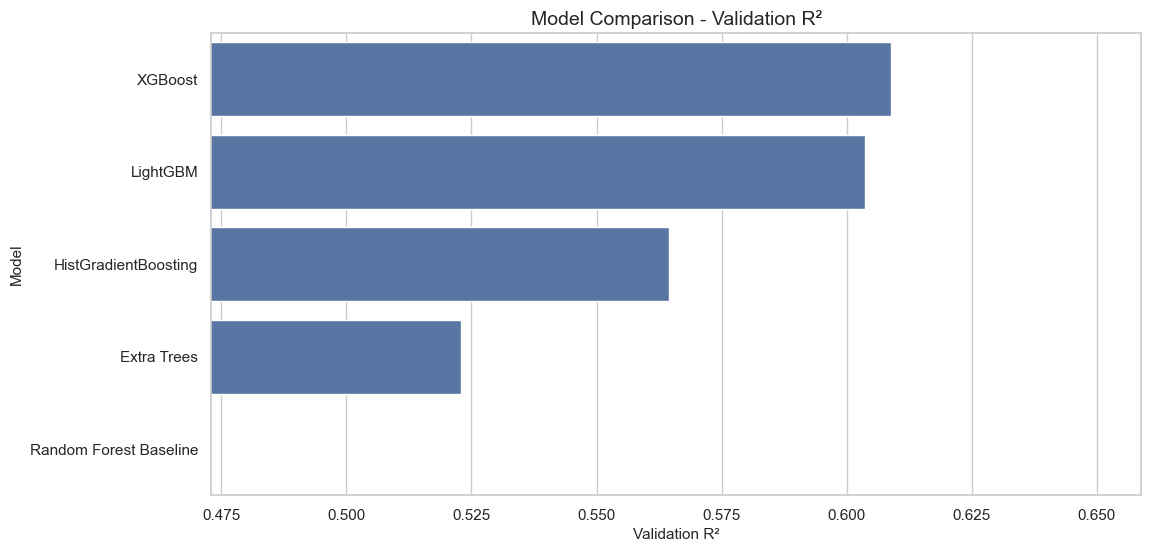

In [50]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=results_df,
    x="Valid_R2",
    y="Model"
)

plt.title("Model Comparison - Validation R²")
plt.xlabel("Validation R²")
plt.ylabel("Model")

plt.xlim(
    max(0, results_df["Valid_R2"].min() - 0.05),
    min(1, results_df["Valid_R2"].max() + 0.05)
)

plt.show()

In [51]:
overfitting_df = results_df[
    [
        "Model",
        "Train_R2",
        "Valid_R2"
    ]
].copy()

overfitting_df["R2_Gap"] = (
    overfitting_df["Train_R2"]
    - overfitting_df["Valid_R2"]
)

overfitting_df.sort_values(
    "R2_Gap",
    ascending=False
)

,Model,Train_R2,Valid_R2,R2_Gap
3,Extra Trees,1.000000,0.523000,0.477000
2,HistGradientBoosting,0.811181,0.564517,0.246664
1,LightGBM,0.675698,0.603632,0.072066
0,XGBoost,0.656176,0.608862,0.047314
4,Random Forest Baseline,NaN,NaN,NaN


In [52]:
X_train_cb = X_train_fe.copy()
X_valid_cb = X_valid_fe.copy()

In [53]:
for col in categorical_features:

    X_train_cb[col] = (
        X_train_cb[col]
        .astype(str)
        .fillna("Missing")
    )

    X_valid_cb[col] = (
        X_valid_cb[col]
        .astype(str)
        .fillna("Missing")
    )

In [54]:
for col in numeric_features:

    median_value = X_train_cb[col].median()

    X_train_cb[col] = (
        X_train_cb[col]
        .fillna(median_value)
    )

    X_valid_cb[col] = (
        X_valid_cb[col]
        .fillna(median_value)
    )

In [55]:
catboost_model = CatBoostRegressor(
    iterations=800,
    learning_rate=0.03,
    depth=6,
    l2_leaf_reg=5,
    loss_function="RMSE",
    random_seed=SEED,
    verbose=False
)

catboost_model.fit(
    X_train_cb,
    y_train,
    cat_features=categorical_features
)

cb_train_pred = catboost_model.predict(
    X_train_cb
)

cb_valid_pred = catboost_model.predict(
    X_valid_cb
)

cb_train_metrics = evaluate_regression(
    y_train,
    cb_train_pred
)

cb_valid_metrics = evaluate_regression(
    y_valid,
    cb_valid_pred
)

catboost_result = {
    "Model": "CatBoost",

    "Train_R2": cb_train_metrics["R2"],
    "Valid_R2": cb_valid_metrics["R2"],

    "Train_MAE": cb_train_metrics["MAE"],
    "Valid_MAE": cb_valid_metrics["MAE"],

    "Train_RMSE": cb_train_metrics["RMSE"],
    "Valid_RMSE": cb_valid_metrics["RMSE"],

    "Valid_Within_10pct": cb_valid_metrics["Within_10pct"],
    "Valid_Within_20pct": cb_valid_metrics["Within_20pct"]
}

results.append(catboost_result)

print(f"Train R²       : {cb_train_metrics['R2']:.4f}")
print(f"Validation R²  : {cb_valid_metrics['R2']:.4f}")
print(f"Validation MAE : {cb_valid_metrics['MAE']:.2f}")
print(f"Validation RMSE: {cb_valid_metrics['RMSE']:.2f}")
print(f"Within ±10%    : {cb_valid_metrics['Within_10pct']:.2%}")
print(f"Within ±20%    : {cb_valid_metrics['Within_20pct']:.2%}")

Train R²       : 0.6298
Validation R²  : 0.6164
Validation MAE : 715.41
Validation RMSE: 1021.09
Within ±10%    : 15.48%
Within ±20%    : 34.84%


In [56]:
results_df = (
    pd.DataFrame(results)
    .sort_values(
        "Valid_R2",
        ascending=False
    )
    .reset_index(drop=True)
)

results_df

,Model,R2,MAE,RMSE,Within_10pct,Within_20pct,Train_R2,Valid_R2,Train_MAE,Valid_MAE,Train_RMSE,Valid_RMSE,Valid_Within_10pct,Valid_Within_20pct
0,CatBoost,NaN,NaN,NaN,NaN,NaN,0.629782,0.616395,7.363237e+02,715.414658,1.046482e+03,1021.091671,0.154839,0.348387
1,XGBoost,NaN,NaN,NaN,NaN,NaN,0.656176,0.608862,7.161266e+02,719.671462,1.008489e+03,1031.068155,0.170674,0.354839
2,LightGBM,NaN,NaN,NaN,NaN,NaN,0.675698,0.603632,6.936068e+02,721.119693,9.794398e+02,1037.939159,0.163050,0.351320
3,HistGradientBoosting,NaN,NaN,NaN,NaN,NaN,0.811181,0.564517,5.424256e+02,752.838847,7.473520e+02,1087.947474,0.161877,0.327273
4,Extra Trees,NaN,NaN,NaN,NaN,NaN,1.000000,0.523000,7.769435e-12,791.386246,1.131843e-11,1138.627265,0.155425,0.306745
5,Random Forest Baseline,0.562435,761.217424,1090.545395,0.154252,0.309677,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [57]:
results_df.to_csv(
    os.path.join(
        REPORT_DIR,
        "baseline_model_comparison.csv"
    ),
    index=False
)

print("Baseline model comparison saved.")

Baseline model comparison saved.


In [58]:
results = []

In [59]:
random_forest = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=300,
                random_state=SEED,
                n_jobs=1
            )
        )
    ]
)

random_forest, rf_result = train_and_evaluate(
    "Random Forest",
    random_forest,
    X_train_fe,
    X_valid_fe,
    y_train,
    y_valid
)

results.append(rf_result)


Training: Random Forest
Train R²       : 0.9389
Validation R²  : 0.5624
Validation MAE : 761.41
Validation RMSE: 1090.61
Within ±10%    : 15.13%
Within ±20%    : 31.09%


In [60]:
extra_trees = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            ExtraTreesRegressor(
                n_estimators=400,
                max_depth=20,
                min_samples_leaf=3,
                min_samples_split=5,
                max_features=0.8,
                random_state=SEED,
                n_jobs=1
            )
        )
    ]
)

extra_trees, extra_trees_result = train_and_evaluate(
    "Extra Trees",
    extra_trees,
    X_train_fe,
    X_valid_fe,
    y_train,
    y_valid
)

results.append(extra_trees_result)


Training: Extra Trees
Train R²       : 0.8036
Validation R²  : 0.5935
Validation MAE : 732.59
Validation RMSE: 1051.12
Within ±10%    : 16.72%
Within ±20%    : 33.31%


In [61]:
hist_gradient = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            HistGradientBoostingRegressor(
                max_iter=500,
                learning_rate=0.05,
                max_leaf_nodes=31,
                min_samples_leaf=20,
                l2_regularization=2.0,
                random_state=SEED
            )
        )
    ]
)

hist_gradient, hist_gradient_result = train_and_evaluate(
    "HistGradientBoosting",
    hist_gradient,
    X_train_fe,
    X_valid_fe,
    y_train,
    y_valid
)

results.append(hist_gradient_result)


Training: HistGradientBoosting
Train R²       : 0.8068
Validation R²  : 0.5650
Validation MAE : 750.98
Validation RMSE: 1087.34
Within ±10%    : 16.95%
Within ±20%    : 33.78%


In [62]:
xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            XGBRegressor(
                n_estimators=500,
                learning_rate=0.03,
                max_depth=4,
                min_child_weight=5,
                subsample=0.8,
                colsample_bytree=0.8,
                reg_alpha=0.1,
                reg_lambda=5.0,
                objective="reg:squarederror",
                random_state=SEED,
                n_jobs=1
            )
        )
    ]
)

xgb_model, xgb_result = train_and_evaluate(
    "XGBoost",
    xgb_model,
    X_train_fe,
    X_valid_fe,
    y_train,
    y_valid
)

results.append(xgb_result)


Training: XGBoost
Train R²       : 0.6562
Validation R²  : 0.6089
Validation MAE : 719.67
Validation RMSE: 1031.07
Within ±10%    : 17.07%
Within ±20%    : 35.48%


In [63]:
lgbm_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LGBMRegressor(
                n_estimators=500,
                learning_rate=0.03,
                max_depth=5,
                num_leaves=31,
                min_child_samples=30,
                subsample=0.8,
                colsample_bytree=0.8,
                reg_alpha=0.1,
                reg_lambda=5.0,
                random_state=SEED,
                n_jobs=1,
                verbosity=-1
            )
        )
    ]
)

lgbm_model, lgbm_result = train_and_evaluate(
    "LightGBM",
    lgbm_model,
    X_train_fe,
    X_valid_fe,
    y_train,
    y_valid
)

results.append(lgbm_result)


Training: LightGBM
Train R²       : 0.6757
Validation R²  : 0.6036
Validation MAE : 721.12
Validation RMSE: 1037.94
Within ±10%    : 16.30%
Within ±20%    : 35.13%


In [64]:
catboost_model = CatBoostRegressor(
    iterations=800,
    learning_rate=0.03,
    depth=6,
    l2_leaf_reg=5,
    loss_function="RMSE",
    random_seed=SEED,
    verbose=False,
    thread_count=1
)

catboost_model.fit(
    X_train_cb,
    y_train,
    cat_features=categorical_features
)

cb_train_pred = catboost_model.predict(X_train_cb)
cb_valid_pred = catboost_model.predict(X_valid_cb)

cb_train_metrics = evaluate_regression(
    y_train,
    cb_train_pred
)

cb_valid_metrics = evaluate_regression(
    y_valid,
    cb_valid_pred
)

catboost_result = {
    "Model": "CatBoost",
    "Train_R2": cb_train_metrics["R2"],
    "Valid_R2": cb_valid_metrics["R2"],
    "Train_MAE": cb_train_metrics["MAE"],
    "Valid_MAE": cb_valid_metrics["MAE"],
    "Train_RMSE": cb_train_metrics["RMSE"],
    "Valid_RMSE": cb_valid_metrics["RMSE"],
    "Valid_Within_10pct": cb_valid_metrics["Within_10pct"],
    "Valid_Within_20pct": cb_valid_metrics["Within_20pct"]
}

results.append(catboost_result)

In [65]:
results_df = (
    pd.DataFrame(results)
    .sort_values(
        "Valid_R2",
        ascending=False
    )
    .reset_index(drop=True)
)

results_df[
    [
        "Model",
        "Train_R2",
        "Valid_R2",
        "Valid_MAE",
        "Valid_RMSE",
        "Valid_Within_10pct",
        "Valid_Within_20pct"
    ]
]

,Model,Train_R2,Valid_R2,Valid_MAE,Valid_RMSE,Valid_Within_10pct,Valid_Within_20pct
0,CatBoost,0.629782,0.616395,715.414658,1021.091671,0.154839,0.348387
1,XGBoost,0.656176,0.608862,719.671462,1031.068155,0.170674,0.354839
2,LightGBM,0.675698,0.603632,721.119693,1037.939159,0.163050,0.351320
3,Extra Trees,0.803590,0.593503,732.594295,1051.116673,0.167155,0.333138
4,HistGradientBoosting,0.806799,0.565003,750.975321,1087.340769,0.169501,0.337830
5,Random Forest,0.938882,0.562380,761.411228,1090.613719,0.151320,0.310850


In [66]:
overfitting_df = results_df[
    [
        "Model",
        "Train_R2",
        "Valid_R2"
    ]
].copy()

overfitting_df["R2_Gap"] = (
    overfitting_df["Train_R2"]
    - overfitting_df["Valid_R2"]
)

overfitting_df = overfitting_df.sort_values(
    "R2_Gap",
    ascending=False
)

overfitting_df

,Model,Train_R2,Valid_R2,R2_Gap
5,Random Forest,0.938882,0.562380,0.376502
4,HistGradientBoosting,0.806799,0.565003,0.241797
3,Extra Trees,0.803590,0.593503,0.210087
2,LightGBM,0.675698,0.603632,0.072066
1,XGBoost,0.656176,0.608862,0.047314
0,CatBoost,0.629782,0.616395,0.013387


In [67]:
results_df[
    [
        "Model",
        "Train_R2",
        "Valid_R2",
        "Valid_MAE",
        "Valid_RMSE",
        "Valid_Within_10pct",
        "Valid_Within_20pct"
    ]
]

,Model,Train_R2,Valid_R2,Valid_MAE,Valid_RMSE,Valid_Within_10pct,Valid_Within_20pct
0,CatBoost,0.629782,0.616395,715.414658,1021.091671,0.154839,0.348387
1,XGBoost,0.656176,0.608862,719.671462,1031.068155,0.170674,0.354839
2,LightGBM,0.675698,0.603632,721.119693,1037.939159,0.163050,0.351320
3,Extra Trees,0.803590,0.593503,732.594295,1051.116673,0.167155,0.333138
4,HistGradientBoosting,0.806799,0.565003,750.975321,1087.340769,0.169501,0.337830
5,Random Forest,0.938882,0.562380,761.411228,1090.613719,0.151320,0.310850


In [68]:
cv = KFold(
    n_splits=3,
    shuffle=True,
    random_state=SEED
)

print("Using 3-fold cross-validation for model selection.")

Using 3-fold cross-validation for model selection.


In [69]:
def cross_validate_model(
    model_name,
    model,
    X_data,
    y_data,
    cv
):
    """
    Perform cross-validation using R².
    """

    print(f"\n{'=' * 70}")
    print(f"Cross-validation: {model_name}")
    print(f"{'=' * 70}")

    scores = cross_val_score(
        model,
        X_data,
        y_data,
        cv=cv,
        scoring="r2",
        n_jobs=1
    )

    print("Fold R² scores:", np.round(scores, 4))
    print(f"Mean R²       : {scores.mean():.4f}")
    print(f"Std R²        : {scores.std():.4f}")

    return {
        "Model": model_name,
        "CV_Mean_R2": scores.mean(),
        "CV_Std_R2": scores.std(),
        "CV_Fold_Scores": scores
    }

In [70]:
from sklearn.model_selection import cross_val_score

In [71]:
xgb_cv = cross_validate_model(
    "XGBoost",
    xgb_model,
    X_train_fe,
    y_train,
    cv
)


Cross-validation: XGBoost
Fold R² scores: [0.5837 0.5765 0.5918]
Mean R²       : 0.5840
Std R²        : 0.0062


In [72]:
lgbm_cv = cross_validate_model(
    "LightGBM",
    lgbm_model,
    X_train_fe,
    y_train,
    cv
)


Cross-validation: LightGBM
Fold R² scores: [0.5756 0.5719 0.5855]
Mean R²       : 0.5777
Std R²        : 0.0057


In [73]:
rf_cv = cross_validate_model(
    "Random Forest",
    random_forest,
    X_train_fe,
    y_train,
    cv
)


Cross-validation: Random Forest
Fold R² scores: [0.5501 0.5401 0.5625]
Mean R²       : 0.5509
Std R²        : 0.0092


In [74]:
extra_trees_cv = cross_validate_model(
    "Extra Trees",
    extra_trees,
    X_train_fe,
    y_train,
    cv
)


Cross-validation: Extra Trees
Fold R² scores: [0.5487 0.5572 0.5673]
Mean R²       : 0.5578
Std R²        : 0.0076


In [75]:
X_cv_cb = X_train_fe.copy()

for col in categorical_features:
    X_cv_cb[col] = X_cv_cb[col].astype(str)

In [76]:
def catboost_cross_validate(
    X_data,
    y_data,
    categorical_features,
    cv
):
    scores = []

    print("=" * 70)
    print("Cross-validation: CatBoost")
    print("=" * 70)

    for fold, (train_idx, valid_idx) in enumerate(
        cv.split(X_data),
        start=1
    ):

        X_fold_train = X_data.iloc[train_idx].copy()
        X_fold_valid = X_data.iloc[valid_idx].copy()

        y_fold_train = y_data.iloc[train_idx]
        y_fold_valid = y_data.iloc[valid_idx]

        model = CatBoostRegressor(
            iterations=500,
            learning_rate=0.03,
            depth=6,
            l2_leaf_reg=5,
            loss_function="RMSE",
            random_seed=SEED,
            thread_count=1,
            verbose=False
        )

        model.fit(
            X_fold_train,
            y_fold_train,
            cat_features=categorical_features,
            eval_set=(X_fold_valid, y_fold_valid),
            early_stopping_rounds=50,
            verbose=False
        )

        predictions = model.predict(X_fold_valid)

        fold_r2 = r2_score(
            y_fold_valid,
            predictions
        )

        scores.append(fold_r2)

        print(
            f"Fold {fold} R²: {fold_r2:.4f}"
        )

    scores = np.array(scores)

    print("-" * 70)
    print(
        f"Mean R²: {scores.mean():.4f}"
    )
    print(
        f"Std R² : {scores.std():.4f}"
    )

    return {
        "Model": "CatBoost",
        "CV_Mean_R2": scores.mean(),
        "CV_Std_R2": scores.std(),
        "CV_Fold_Scores": scores
    }

In [77]:
catboost_cv = catboost_cross_validate(
    X_cv_cb,
    y_train,
    categorical_features,
    cv
)

Cross-validation: CatBoost
Fold 1 R²: 0.5926
Fold 2 R²: 0.5946
Fold 3 R²: 0.6024
----------------------------------------------------------------------
Mean R²: 0.5965
Std R² : 0.0042


In [78]:
cv_results = pd.DataFrame([
    xgb_cv,
    lgbm_cv,
    catboost_cv
])

cv_results[
    [
        "Model",
        "CV_Mean_R2",
        "CV_Std_R2"
    ]
].sort_values(
    "CV_Mean_R2",
    ascending=False
).reset_index(drop=True)

,Model,CV_Mean_R2,CV_Std_R2
0,CatBoost,0.596535,0.004237
1,XGBoost,0.583982,0.006239
2,LightGBM,0.577677,0.005746


In [79]:
%pip install optuna

Note: you may need to restart the kernel to use updated packages.


In [80]:
import optuna

In [81]:
X_optuna = X_train_fe.copy()

for col in categorical_features:
    X_optuna[col] = X_optuna[col].astype(str)

print(X_optuna.shape)

(6818, 19)


In [82]:
def objective(trial):

    params = {
        "iterations": trial.suggest_int(
            "iterations",
            500,
            1500
        ),

        "depth": trial.suggest_int(
            "depth",
            4,
            9
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.08,
            log=True
        ),

        "l2_leaf_reg": trial.suggest_float(
            "l2_leaf_reg",
            1.0,
            20.0,
            log=True
        ),

        "random_strength": trial.suggest_float(
            "random_strength",
            0.0,
            2.0
        ),

        "bagging_temperature": trial.suggest_float(
            "bagging_temperature",
            0.0,
            2.0
        ),

        "loss_function": "RMSE",
        "random_seed": SEED,
        "thread_count": 1,
        "verbose": False
    }

    fold_scores = []

    for train_idx, valid_idx in cv.split(X_optuna):

        X_fold_train = X_optuna.iloc[train_idx]
        X_fold_valid = X_optuna.iloc[valid_idx]

        y_fold_train = y_train.iloc[train_idx]
        y_fold_valid = y_train.iloc[valid_idx]

        model = CatBoostRegressor(**params)

        model.fit(
            X_fold_train,
            y_fold_train,
            cat_features=categorical_features,
            eval_set=(X_fold_valid, y_fold_valid),
            early_stopping_rounds=50,
            verbose=False
        )

        predictions = model.predict(X_fold_valid)

        score = r2_score(
            y_fold_valid,
            predictions
        )

        fold_scores.append(score)

    return np.mean(fold_scores)

In [83]:
study = optuna.create_study(
    direction="maximize",
    study_name="BigMart_CatBoost_Optimization"
)

study.optimize(
    objective,
    n_trials=30
)

[I 2026-08-31 10:33:07,745] A new study created in memory with name: BigMart_CatBoost_Optimization
[I 2026-08-31 10:34:24,626] Trial 0 finished with value: 0.5959357187763362 and parameters: {'iterations': 876, 'depth': 9, 'learning_rate': 0.06645922216307956, 'l2_leaf_reg': 3.177772772515067, 'random_strength': 1.5162796494986095, 'bagging_temperature': 1.6413879262795747}. Best is trial 0 with value: 0.5959357187763362.
[I 2026-08-31 10:35:14,117] Trial 1 finished with value: 0.5962298140253944 and parameters: {'iterations': 1131, 'depth': 8, 'learning_rate': 0.07532707848201262, 'l2_leaf_reg': 1.428650167153469, 'random_strength': 1.2928711533652362, 'bagging_temperature': 0.44826912414388076}. Best is trial 1 with value: 0.5962298140253944.
[I 2026-08-31 10:37:10,529] Trial 2 finished with value: 0.5966192371452549 and parameters: {'iterations': 1014, 'depth': 5, 'learning_rate': 0.011429611031339838, 'l2_leaf_reg': 3.166578186487907, 'random_strength': 1.572373907549201, 'bagging_

In [84]:
print("Best CV R²:")
print(study.best_value)

print("\nBest Parameters:")
for key, value in study.best_params.items():
    print(f"{key}: {value}")

Best CV R²:
0.5982968768491034

Best Parameters:
iterations: 868
depth: 4
learning_rate: 0.01627204730859155
l2_leaf_reg: 6.859618252461538
random_strength: 0.6635314578861797
bagging_temperature: 1.5089695392792097


In [85]:
def feature_engineering_v2(df):
    df = df.copy()

    # -----------------------------
    # Existing features
    # -----------------------------

    # Outlet age
    df["Outlet_Age"] = (
        2026 - df["Outlet_Establishment_Year"]
    )

    # Item identifier prefix
    df["Item_ID_Category"] = (
        df["Item_Identifier"]
        .astype(str)
        .str[:2]
    )

    # Visibility features
    df["Item_Visibility_Zero"] = (
        df["Item_Visibility"] == 0
    ).astype(int)

    df["Item_Visibility_Log"] = np.log1p(
        df["Item_Visibility"]
    )

    # MRP features
    df["Item_MRP_Log"] = np.log1p(
        df["Item_MRP"]
    )

    # Avoid division by zero
    weight_safe = df["Item_Weight"].fillna(
        df["Item_Weight"].median()
    )

    mrp_safe = df["Item_MRP"].clip(lower=1e-6)

    # -----------------------------
    # New ratio features
    # -----------------------------

    df["MRP_Per_Weight"] = (
        df["Item_MRP"] /
        (weight_safe + 1e-6)
    )

    df["Visibility_Per_MRP"] = (
        df["Item_Visibility"] /
        mrp_safe
    )

    # -----------------------------
    # Interaction features
    # -----------------------------

    df["MRP_Visibility"] = (
        df["Item_MRP"] *
        df["Item_Visibility"]
    )

    df["MRP_Weight"] = (
        df["Item_MRP"] *
        weight_safe
    )

    df["Visibility_Weight"] = (
        df["Item_Visibility"] *
        weight_safe
    )

    # -----------------------------
    # Age transformations
    # -----------------------------

    df["Outlet_Age_Squared"] = (
        df["Outlet_Age"] ** 2
    )

    # -----------------------------
    # Store / product interaction
    # -----------------------------

    df["Item_Type_Outlet_Type"] = (
        df["Item_Type"].astype(str)
        + "_"
        + df["Outlet_Type"].astype(str)
    )

    df["Item_Category_Outlet_Type"] = (
        df["Item_ID_Category"].astype(str)
        + "_"
        + df["Outlet_Type"].astype(str)
    )

    df["Fat_Content_Outlet_Type"] = (
        df["Item_Fat_Content"].astype(str)
        + "_"
        + df["Outlet_Type"].astype(str)
    )

    return df

In [86]:
X_train_v2 = feature_engineering_v2(
    clean_data(X_train)
)

X_valid_v2 = feature_engineering_v2(
    clean_data(X_valid)
)

print("Original features:", X_train_fe.shape)
print("Enhanced features:", X_train_v2.shape)

Original features: (6818, 19)
Enhanced features: (6818, 25)


In [87]:
categorical_features_v2 = (
    X_train_v2
    .select_dtypes(include=["object"])
    .columns
    .tolist()
)

for col in categorical_features_v2:
    X_train_v2[col] = X_train_v2[col].astype(str)
    X_valid_v2[col] = X_valid_v2[col].astype(str)

print("Categorical features:", categorical_features_v2)

Categorical features: ['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Outlet_Identifier', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type', 'Item_ID_Category', 'Item_Type_Outlet_Type', 'Item_Category_Outlet_Type', 'Fat_Content_Outlet_Type']


In [88]:
catboost_v2 = CatBoostRegressor(
    iterations=990,
    depth=4,
    learning_rate=0.039965,
    l2_leaf_reg=2.80586,
    random_strength=1.15575,
    bagging_temperature=0.50767,
    loss_function="RMSE",
    random_seed=SEED,
    thread_count=1,
    verbose=False
)

catboost_v2.fit(
    X_train_v2,
    y_train,
    cat_features=categorical_features_v2
)

CatBoostRegressor(bagging_temperature=0.50767, depth=4, iterations=990, l2_leaf_reg=2.80586, learning_rate=0.039965, loss_function='RMSE', random_seed=42, random_strength=1.15575, thread_count=1, verbose=False)

In [89]:
v2_train_pred = catboost_v2.predict(
    X_train_v2
)

v2_valid_pred = catboost_v2.predict(
    X_valid_v2
)

v2_train_metrics = evaluate_regression(
    y_train,
    v2_train_pred
)

v2_valid_metrics = evaluate_regression(
    y_valid,
    v2_valid_pred
)

print("Train R²       :", round(v2_train_metrics["R2"], 4))
print("Validation R²  :", round(v2_valid_metrics["R2"], 4))
print("Validation MAE :", round(v2_valid_metrics["MAE"], 2))
print("Validation RMSE:", round(v2_valid_metrics["RMSE"], 2))
print("Within ±10%    :", f"{v2_valid_metrics['Within_10pct']:.2%}")
print("Within ±20%    :", f"{v2_valid_metrics['Within_20pct']:.2%}")

Train R²       : 0.6278
Validation R²  : 0.6121
Validation MAE : 718.92
Validation RMSE: 1026.75
Within ±10%    : 15.54%
Within ±20%    : 34.25%


In [90]:
y_train_log = np.log1p(y_train)

print("Original target:")
print(y_train.describe())

print("\nLog-transformed target:")
print(y_train_log.describe())

Original target:
count     6818.000000
mean      2202.365231
std       1720.024464
min         33.290000
25%        851.225300
50%       1808.312800
75%       3123.933600
max      13086.964800
Name: Item_Outlet_Sales, dtype: float64

Log-transformed target:
count    6818.000000
mean        7.309469
std         1.012327
min         3.534854
25%         6.747851
50%         7.500702
75%         8.047168
max         9.479448
Name: Item_Outlet_Sales, dtype: float64


In [91]:
catboost_log = CatBoostRegressor(
    iterations=990,
    depth=4,
    learning_rate=0.039965,
    l2_leaf_reg=2.80586,
    random_strength=1.15575,
    bagging_temperature=0.50767,
    loss_function="RMSE",
    random_seed=SEED,
    thread_count=1,
    verbose=False
)

catboost_log.fit(
    X_train_cb,
    y_train_log,
    cat_features=categorical_features
)

CatBoostRegressor(bagging_temperature=0.50767, depth=4, iterations=990, l2_leaf_reg=2.80586, learning_rate=0.039965, loss_function='RMSE', random_seed=42, random_strength=1.15575, thread_count=1, verbose=False)

In [92]:
log_train_pred = catboost_log.predict(X_train_cb)
log_valid_pred = catboost_log.predict(X_valid_cb)

train_pred_original = np.expm1(log_train_pred)
valid_pred_original = np.expm1(log_valid_pred)

In [93]:
log_train_metrics = evaluate_regression(
    y_train,
    train_pred_original
)

log_valid_metrics = evaluate_regression(
    y_valid,
    valid_pred_original
)

print("Train R²       :", round(log_train_metrics["R2"], 4))
print("Validation R²  :", round(log_valid_metrics["R2"], 4))
print("Validation MAE :", round(log_valid_metrics["MAE"], 2))
print("Validation RMSE:", round(log_valid_metrics["RMSE"], 2))
print("Within ±10%    :", f"{log_valid_metrics['Within_10pct']:.2%}")
print("Within ±20%    :", f"{log_valid_metrics['Within_20pct']:.2%}")

Train R²       : 0.5992
Validation R²  : 0.6022
Validation MAE : 714.19
Validation RMSE: 1039.78
Within ±10%    : 17.36%
Within ±20%    : 33.14%


In [94]:
weight_by_type = (
    train.groupby("Item_Type")["Item_Weight"]
    .agg(
        count="count",
        missing="size"
    )
)

weight_by_type

,count,missing
Item_Type,,
Baking Goods,536,648
Breads,204,251
Breakfast,89,110
Canned,539,649
Dairy,566,682
Frozen Foods,718,856
Fruits and Vegetables,1019,1232
Hard Drinks,183,214
Health and Hygiene,430,520


In [95]:
weight_summary = (
    train.groupby("Item_Type")["Item_Weight"]
    .agg(
        Count="count",
        Missing=lambda x: x.isna().sum(),
        Median="median"
    )
    .sort_values("Missing", ascending=False)
)

weight_summary

,Count,Missing,Median
Item_Type,,,
Fruits and Vegetables,1019,213,13.100
Snack Foods,988,212,13.150
Household,759,151,13.150
Frozen Foods,718,138,12.850
Dairy,566,116,13.350
Baking Goods,536,112,11.650
Canned,539,110,12.150
Health and Hygiene,430,90,12.150
Meat,337,88,12.350


In [96]:
def impute_item_weight(train_df, valid_df):
    train_df = train_df.copy()
    valid_df = valid_df.copy()

    # Learn medians from training data only
    type_medians = (
        train_df
        .groupby("Item_Type")["Item_Weight"]
        .median()
    )

    global_median = (
        train_df["Item_Weight"]
        .median()
    )

    # Training
    train_df["Item_Weight"] = (
        train_df["Item_Weight"]
        .fillna(
            train_df["Item_Type"].map(type_medians)
        )
        .fillna(global_median)
    )

    # Validation
    valid_df["Item_Weight"] = (
        valid_df["Item_Weight"]
        .fillna(
            valid_df["Item_Type"].map(type_medians)
        )
        .fillna(global_median)
    )

    return train_df, valid_df

In [97]:
def impute_outlet_size(train_df, valid_df):
    train_df = train_df.copy()
    valid_df = valid_df.copy()

    # Learn mapping from training data only
    outlet_mapping = (
        train_df
        .groupby("Outlet_Identifier")["Outlet_Size"]
        .agg(
            lambda x: x.mode().iloc[0]
            if not x.mode().empty
            else np.nan
        )
    )

    type_mapping = (
        train_df
        .groupby("Outlet_Type")["Outlet_Size"]
        .agg(
            lambda x: x.mode().iloc[0]
            if not x.mode().empty
            else np.nan
        )
    )

    global_mode = (
        train_df["Outlet_Size"]
        .mode()
        .iloc[0]
    )

    for df in [train_df, valid_df]:

        df["Outlet_Size"] = (
            df["Outlet_Size"]
            .fillna(
                df["Outlet_Identifier"]
                .map(outlet_mapping)
            )
            .fillna(
                df["Outlet_Type"]
                .map(type_mapping)
            )
            .fillna(global_mode)
        )

    return train_df, valid_df

In [98]:
def preprocess_v3(train_df, valid_df):
    train_df = train_df.copy()
    valid_df = valid_df.copy()

    # ------------------------------------------------
    # 1. Missing-value indicators
    # ------------------------------------------------

    train_df["Item_Weight_Missing"] = (
        train_df["Item_Weight"].isna().astype(int)
    )

    valid_df["Item_Weight_Missing"] = (
        valid_df["Item_Weight"].isna().astype(int)
    )

    train_df["Outlet_Size_Missing"] = (
        train_df["Outlet_Size"].isna().astype(int)
    )

    valid_df["Outlet_Size_Missing"] = (
        valid_df["Outlet_Size"].isna().astype(int)
    )

    # ------------------------------------------------
    # 2. Item Weight imputation
    #    Learn only from training data
    # ------------------------------------------------

    weight_medians = (
        train_df
        .groupby("Item_Type")["Item_Weight"]
        .median()
    )

    global_weight_median = (
        train_df["Item_Weight"].median()
    )

    train_df["Item_Weight"] = (
        train_df["Item_Weight"]
        .fillna(
            train_df["Item_Type"].map(weight_medians)
        )
        .fillna(global_weight_median)
    )

    valid_df["Item_Weight"] = (
        valid_df["Item_Weight"]
        .fillna(
            valid_df["Item_Type"].map(weight_medians)
        )
        .fillna(global_weight_median)
    )

    # ------------------------------------------------
    # 3. Outlet Size imputation
    # ------------------------------------------------

    outlet_size_map = (
        train_df
        .groupby("Outlet_Identifier")["Outlet_Size"]
        .agg(
            lambda x: x.mode().iloc[0]
            if not x.mode().empty
            else np.nan
        )
    )

    outlet_type_map = (
        train_df
        .groupby("Outlet_Type")["Outlet_Size"]
        .agg(
            lambda x: x.mode().iloc[0]
            if not x.mode().empty
            else np.nan
        )
    )

    global_outlet_size = (
        train_df["Outlet_Size"]
        .mode()
        .iloc[0]
    )

    train_df["Outlet_Size"] = (
        train_df["Outlet_Size"]
        .fillna(
            train_df["Outlet_Identifier"]
            .map(outlet_size_map)
        )
        .fillna(
            train_df["Outlet_Type"]
            .map(outlet_type_map)
        )
        .fillna(global_outlet_size)
    )

    valid_df["Outlet_Size"] = (
        valid_df["Outlet_Size"]
        .fillna(
            valid_df["Outlet_Identifier"]
            .map(outlet_size_map)
        )
        .fillna(
            valid_df["Outlet_Type"]
            .map(outlet_type_map)
        )
        .fillna(global_outlet_size)
    )

    return train_df, valid_df

In [99]:
X_train_v3_raw, X_valid_v3_raw = preprocess_v3(
    X_train,
    X_valid
)

print("Missing values after V3 preprocessing:")
print(
    X_train_v3_raw.isnull().sum()
    .sort_values(ascending=False)
    .head(10)
)

Missing values after V3 preprocessing:
Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
dtype: int64


In [100]:
X_train_v3 = feature_engineering(
    X_train_v3_raw
)

X_valid_v3 = feature_engineering(
    X_valid_v3_raw
)

print("V3 training shape:", X_train_v3.shape)
print("V3 validation shape:", X_valid_v3.shape)

V3 training shape: (6818, 21)
V3 validation shape: (1705, 21)


In [101]:
categorical_features_v3 = (
    X_train_v3
    .select_dtypes(include=["object"])
    .columns
    .tolist()
)

print("Categorical features:")
print(categorical_features_v3)

Categorical features:
['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Outlet_Identifier', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type', 'Item_ID_Category']


In [102]:
for col in categorical_features_v3:
    X_train_v3[col] = X_train_v3[col].astype(str)
    X_valid_v3[col] = X_valid_v3[col].astype(str)

In [103]:
catboost_v3 = CatBoostRegressor(
    iterations=990,
    depth=4,
    learning_rate=0.039965,
    l2_leaf_reg=2.80586,
    random_strength=1.15575,
    bagging_temperature=0.50767,
    loss_function="RMSE",
    random_seed=SEED,
    thread_count=1,
    verbose=False
)

catboost_v3.fit(
    X_train_v3,
    y_train,
    cat_features=categorical_features_v3
)

CatBoostRegressor(bagging_temperature=0.50767, depth=4, iterations=990, l2_leaf_reg=2.80586, learning_rate=0.039965, loss_function='RMSE', random_seed=42, random_strength=1.15575, thread_count=1, verbose=False)

In [104]:
v3_train_pred = catboost_v3.predict(
    X_train_v3
)

v3_valid_pred = catboost_v3.predict(
    X_valid_v3
)

v3_train_metrics = evaluate_regression(
    y_train,
    v3_train_pred
)

v3_valid_metrics = evaluate_regression(
    y_valid,
    v3_valid_pred
)

print("Train R²       :", round(v3_train_metrics["R2"], 4))
print("Validation R²  :", round(v3_valid_metrics["R2"], 4))
print("Validation MAE :", round(v3_valid_metrics["MAE"], 2))
print("Validation RMSE:", round(v3_valid_metrics["RMSE"], 2))
print("Within ±10%    :", f"{v3_valid_metrics['Within_10pct']:.2%}")
print("Within ±20%    :", f"{v3_valid_metrics['Within_20pct']:.2%}")

Train R²       : 0.6256
Validation R²  : 0.6127
Validation MAE : 719.48
Validation RMSE: 1025.98
Within ±10%    : 16.89%
Within ±20%    : 33.61%


In [105]:
comparison = pd.DataFrame({
    "Experiment": [
        "Original CatBoost",
        "V2 Feature Engineering",
        "Log Target",
        "V3 Missing Value Strategy"
    ],
    "Validation_R2": [
        0.616395,
        0.6121,
        0.6022,
        v3_valid_metrics["R2"]
    ],
    "Validation_MAE": [
        715.414658,
        718.92,
        714.19,
        v3_valid_metrics["MAE"]
    ],
    "Validation_RMSE": [
        1021.091671,
        1026.75,
        1039.78,
        v3_valid_metrics["RMSE"]
    ],
    "Within_10pct": [
        0.154839,
        0.1554,
        0.1736,
        v3_valid_metrics["Within_10pct"]
    ],
    "Within_20pct": [
        0.348387,
        0.3425,
        0.3314,
        v3_valid_metrics["Within_20pct"]
    ]
})

comparison.sort_values(
    "Validation_R2",
    ascending=False
).reset_index(drop=True)

,Experiment,Validation_R2,Validation_MAE,Validation_RMSE,Within_10pct,Within_20pct
0,Original CatBoost,0.616395,715.414658,1021.091671,0.154839,0.348387
1,V3 Missing Value Strategy,0.612710,719.478408,1025.983525,0.168915,0.336070
2,V2 Feature Engineering,0.612100,718.920000,1026.750000,0.155400,0.342500
3,Log Target,0.602200,714.190000,1039.780000,0.173600,0.331400


In [106]:
item_weight_check = (
    train.groupby("Item_Identifier")["Item_Weight"]
    .agg(
        count="count",
        missing=lambda x: x.isna().sum(),
        median="median"
    )
)

item_weight_check.head(20)

,count,missing,median
Item_Identifier,,,
DRA12,6,0,11.600
DRA24,5,2,19.350
DRA59,6,2,8.270
DRB01,2,1,7.390
DRB13,5,0,6.115
DRB24,4,0,8.785
DRB25,5,1,12.300
DRB48,6,1,16.750
DRC01,5,1,5.920


In [107]:
known_item_weights = (
    train.groupby("Item_Identifier")["Item_Weight"]
    .transform("median")
)

print(
    "Rows that can be filled using Item_Identifier:",
    train["Item_Weight"].isna()
    .where(known_item_weights.notna())
    .sum()
)

Rows that can be filled using Item_Identifier: 1459


In [108]:
def preprocess_v4(train_df, valid_df):

    train_df = train_df.copy()
    valid_df = valid_df.copy()

    # ==========================================
    # 1. Missingness indicators
    # ==========================================

    train_df["Item_Weight_Missing"] = (
        train_df["Item_Weight"].isna().astype(int)
    )

    valid_df["Item_Weight_Missing"] = (
        valid_df["Item_Weight"].isna().astype(int)
    )

    train_df["Outlet_Size_Missing"] = (
        train_df["Outlet_Size"].isna().astype(int)
    )

    valid_df["Outlet_Size_Missing"] = (
        valid_df["Outlet_Size"].isna().astype(int)
    )

    # ==========================================
    # 2. Item Weight
    # Item Identifier → Item Type → global
    # ==========================================

    item_weight_map = (
        train_df
        .groupby("Item_Identifier")["Item_Weight"]
        .median()
    )

    item_type_weight_map = (
        train_df
        .groupby("Item_Type")["Item_Weight"]
        .median()
    )

    global_weight = train_df["Item_Weight"].median()

    train_df["Item_Weight"] = (
        train_df["Item_Weight"]
        .fillna(
            train_df["Item_Identifier"]
            .map(item_weight_map)
        )
        .fillna(
            train_df["Item_Type"]
            .map(item_type_weight_map)
        )
        .fillna(global_weight)
    )

    valid_df["Item_Weight"] = (
        valid_df["Item_Weight"]
        .fillna(
            valid_df["Item_Identifier"]
            .map(item_weight_map)
        )
        .fillna(
            valid_df["Item_Type"]
            .map(item_type_weight_map)
        )
        .fillna(global_weight)
    )

    # ==========================================
    # 3. Outlet Size
    # Outlet Identifier → Outlet Type → global
    # ==========================================

    outlet_size_map = (
        train_df
        .groupby("Outlet_Identifier")["Outlet_Size"]
        .agg(
            lambda x:
            x.mode().iloc[0]
            if not x.mode().empty
            else np.nan
        )
    )

    outlet_type_map = (
        train_df
        .groupby("Outlet_Type")["Outlet_Size"]
        .agg(
            lambda x:
            x.mode().iloc[0]
            if not x.mode().empty
            else np.nan
        )
    )

    global_outlet_size = (
        train_df["Outlet_Size"]
        .mode()
        .iloc[0]
    )

    train_df["Outlet_Size"] = (
        train_df["Outlet_Size"]
        .fillna(
            train_df["Outlet_Identifier"]
            .map(outlet_size_map)
        )
        .fillna(
            train_df["Outlet_Type"]
            .map(outlet_type_map)
        )
        .fillna(global_outlet_size)
    )

    valid_df["Outlet_Size"] = (
        valid_df["Outlet_Size"]
        .fillna(
            valid_df["Outlet_Identifier"]
            .map(outlet_size_map)
        )
        .fillna(
            valid_df["Outlet_Type"]
            .map(outlet_type_map)
        )
        .fillna(global_outlet_size)
    )

    return train_df, valid_df

In [109]:
X_train_v4_raw, X_valid_v4_raw = preprocess_v4(
    X_train,
    X_valid
)

X_train_v4 = feature_engineering(
    X_train_v4_raw
)

X_valid_v4 = feature_engineering(
    X_valid_v4_raw
)

print("V4 train shape:", X_train_v4.shape)
print("V4 valid shape:", X_valid_v4.shape)

V4 train shape: (6818, 21)
V4 valid shape: (1705, 21)


In [110]:
categorical_features_v4 = (
    X_train_v4
    .select_dtypes(include=["object"])
    .columns
    .tolist()
)

for col in categorical_features_v4:
    X_train_v4[col] = X_train_v4[col].astype(str)
    X_valid_v4[col] = X_valid_v4[col].astype(str)

In [111]:
catboost_v4 = CatBoostRegressor(
    iterations=990,
    depth=4,
    learning_rate=0.039965,
    l2_leaf_reg=2.80586,
    random_strength=1.15575,
    bagging_temperature=0.50767,
    loss_function="RMSE",
    random_seed=SEED,
    thread_count=1,
    verbose=False
)

catboost_v4.fit(
    X_train_v4,
    y_train,
    cat_features=categorical_features_v4
)

CatBoostRegressor(bagging_temperature=0.50767, depth=4, iterations=990, l2_leaf_reg=2.80586, learning_rate=0.039965, loss_function='RMSE', random_seed=42, random_strength=1.15575, thread_count=1, verbose=False)

In [112]:
v4_train_pred = catboost_v4.predict(
    X_train_v4
)

v4_valid_pred = catboost_v4.predict(
    X_valid_v4
)

v4_train_metrics = evaluate_regression(
    y_train,
    v4_train_pred
)

v4_valid_metrics = evaluate_regression(
    y_valid,
    v4_valid_pred
)

print(
    "Train R²       :",
    round(v4_train_metrics["R2"], 4)
)

print(
    "Validation R²  :",
    round(v4_valid_metrics["R2"], 4)
)

print(
    "Validation MAE :",
    round(v4_valid_metrics["MAE"], 2)
)

print(
    "Validation RMSE:",
    round(v4_valid_metrics["RMSE"], 2)
)

print(
    "Within ±10%    :",
    f"{v4_valid_metrics['Within_10pct']:.2%}"
)

print(
    "Within ±20%    :",
    f"{v4_valid_metrics['Within_20pct']:.2%}"
)

Train R²       : 0.629
Validation R²  : 0.6108
Validation MAE : 720.7
Validation RMSE: 1028.53
Within ±10%    : 15.66%
Within ±20%    : 33.61%


In [113]:
X_train_te = X_train_fe.reset_index(drop=True).copy()
X_valid_te = X_valid_fe.reset_index(drop=True).copy()

y_train_te = y_train.reset_index(drop=True)
y_valid_te = y_valid.reset_index(drop=True)

target_encode_columns = [
    "Item_Type",
    "Outlet_Identifier",
    "Outlet_Type",
    "Outlet_Location_Type",
    "Item_ID_Category"
]

In [114]:
def target_encode_oof(
    X_train,
    y_train,
    X_valid,
    columns,
    n_splits=3,
    alpha=10
):
    X_train_encoded = X_train.copy()
    X_valid_encoded = X_valid.copy()

    kf = KFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=SEED
    )

    for column in columns:

        oof_values = pd.Series(
            index=X_train.index,
            dtype=float
        )

        # -----------------------------
        # OOF encoding for training data
        # -----------------------------
        for train_idx, fold_idx in kf.split(X_train):

            fold_train = X_train.iloc[train_idx]
            fold_valid = X_train.iloc[fold_idx]

            y_fold = y_train.iloc[train_idx]

            global_mean = y_fold.mean()

            stats = pd.DataFrame({
                "category": fold_train[column].values,
                "target": y_fold.values
            })

            grouped = (
                stats.groupby("category")["target"]
                .agg(["mean", "count"])
            )

            grouped["encoding"] = (
                grouped["mean"] * grouped["count"]
                + global_mean * alpha
            ) / (
                grouped["count"] + alpha
            )

            oof_values.iloc[fold_idx] = (
                fold_valid[column]
                .map(grouped["encoding"])
                .fillna(global_mean)
                .values
            )

        X_train_encoded[
            f"{column}_TargetMean"
        ] = oof_values.values

        # -----------------------------
        # Validation encoding
        # Learn from ALL training data
        # -----------------------------
        global_mean = y_train.mean()

        stats = pd.DataFrame({
            "category": X_train[column].values,
            "target": y_train.values
        })

        grouped = (
            stats.groupby("category")["target"]
            .agg(["mean", "count"])
        )

        grouped["encoding"] = (
            grouped["mean"] * grouped["count"]
            + global_mean * alpha
        ) / (
            grouped["count"] + alpha
        )

        X_valid_encoded[
            f"{column}_TargetMean"
        ] = (
            X_valid[column]
            .map(grouped["encoding"])
            .fillna(global_mean)
        )

    return X_train_encoded, X_valid_encoded

In [115]:
X_train_te, X_valid_te = target_encode_oof(
    X_train_te,
    y_train_te,
    X_valid_te,
    target_encode_columns,
    n_splits=3,
    alpha=10
)

In [116]:
target_mean_columns = [
    col
    for col in X_train_te.columns
    if "TargetMean" in col
]

X_train_te[target_mean_columns].head()

,Item_Type_TargetMean,Outlet_Identifier_TargetMean,Outlet_Type_TargetMean,Outlet_Location_Type_TargetMean,Item_ID_Category_TargetMean
0,2350.623132,2424.112586,2362.167039,1954.300728,2267.991375
1,2228.079844,2228.295644,2307.942853,2326.295737,2110.504413
2,2230.679640,2240.680835,2307.942853,1852.955160,2216.071631
3,2335.495553,2228.295644,2307.942853,2326.295737,2216.071631
4,2284.823734,2240.680835,2307.942853,1852.955160,2216.071631


In [117]:
X_train_xgb_te = X_train_te.drop(
    columns=categorical_features,
    errors="ignore"
)

X_valid_xgb_te = X_valid_te.drop(
    columns=categorical_features,
    errors="ignore"
)

print("Training shape:", X_train_xgb_te.shape)
print("Validation shape:", X_valid_xgb_te.shape)

Training shape: (6818, 16)
Validation shape: (1705, 16)


In [118]:
xgb_te = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=4,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=5.0,
    objective="reg:squarederror",
    random_state=SEED,
    n_jobs=1
)

xgb_te.fit(
    X_train_xgb_te,
    y_train_te
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=5, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=1, num_parallel_tree=None, ...)

In [119]:
te_train_pred = xgb_te.predict(
    X_train_xgb_te
)

te_valid_pred = xgb_te.predict(
    X_valid_xgb_te
)

te_train_metrics = evaluate_regression(
    y_train_te,
    te_train_pred
)

te_valid_metrics = evaluate_regression(
    y_valid_te,
    te_valid_pred
)

print(
    "Train R²       :",
    round(te_train_metrics["R2"], 4)
)

print(
    "Validation R²  :",
    round(te_valid_metrics["R2"], 4)
)

print(
    "Validation MAE :",
    round(te_valid_metrics["MAE"], 2)
)

print(
    "Validation RMSE:",
    round(te_valid_metrics["RMSE"], 2)
)

print(
    "Within ±10%    :",
    f"{te_valid_metrics['Within_10pct']:.2%}"
)

print(
    "Within ±20%    :",
    f"{te_valid_metrics['Within_20pct']:.2%}"
)

Train R²       : 0.6866
Validation R²  : 0.6087
Validation MAE : 721.82
Validation RMSE: 1031.24
Within ±10%    : 16.30%
Within ±20%    : 33.67%


In [120]:
error_analysis = X_valid_fe.copy()

error_analysis["Actual"] = y_valid.reset_index(drop=True)

error_analysis["Predicted"] = (
    catboost_model.predict(
        X_valid_cb
    )
)

error_analysis["Absolute_Error"] = (
    np.abs(
        error_analysis["Actual"]
        - error_analysis["Predicted"]
    )
)

error_analysis["Percentage_Error"] = (
    error_analysis["Absolute_Error"]
    /
    np.maximum(
        error_analysis["Actual"],
        1e-6
    )
) * 100

error_analysis.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,...,Item_Visibility_Zero,Item_Visibility_Log,Item_MRP_Log,MRP_Per_Weight,Visibility_Per_MRP,MRP_Visibility,Actual,Predicted,Absolute_Error,Percentage_Error
7503,FDI28,14.300,Low Fat,0.026300,Frozen Foods,79.4302,OUT013,1987,High,Tier 3,...,0,0.025960,4.387390,5.554559,0.000331,2.088998,NaN,1221.185133,NaN,NaN
2957,NCM17,7.930,Low Fat,0.071136,Health and Hygiene,42.7086,OUT046,1997,Small,Tier 1,...,0,0.068720,3.777545,5.385699,0.001666,3.038113,NaN,693.265533,NaN,NaN
7031,FDC14,14.500,Regular,0.041313,Canned,42.0454,OUT049,1999,Medium,Tier 1,...,0,0.040483,3.762255,2.899683,0.000983,1.737030,NaN,646.244027,NaN,NaN
1084,DRC36,NaN,Regular,0.044767,Soft Drinks,173.7054,OUT027,1985,Medium,Tier 3,...,0,0.043794,5.163101,NaN,0.000258,7.776275,1998.7316,4641.285922,2642.554322,132.211565
856,FDS27,10.195,Regular,0.012456,Meat,197.5110,OUT035,2004,Small,Tier 2,...,0,0.012379,5.290845,19.373318,0.000063,2.460155,1448.1150,3455.544224,2007.429224,138.623605


In [121]:
error_analysis[
    [
        "Actual",
        "Predicted",
        "Absolute_Error",
        "Percentage_Error"
    ]
].describe()

,Actual,Predicted,Absolute_Error,Percentage_Error
count,369.000000,1705.000000,369.000000,369.000000
mean,2070.300589,2127.394019,1666.210548,289.704399
std,1587.342722,1333.681530,1306.883628,813.512160
min,41.945400,-1.963434,1.629068,0.065703
25%,782.980800,977.012300,571.351160,35.611163
50%,1705.113800,2003.547470,1427.740276,68.635460
75%,2984.115600,3016.297172,2416.745907,155.049125
max,8388.414200,6590.480475,6590.560065,11622.283366


In [122]:
worst_predictions = (
    error_analysis
    .sort_values(
        "Absolute_Error",
        ascending=False
    )
    .head(20)
)

worst_predictions[
    [
        "Item_Identifier",
        "Item_Type",
        "Item_MRP",
        "Item_Visibility",
        "Outlet_Identifier",
        "Outlet_Type",
        "Outlet_Size",
        "Actual",
        "Predicted",
        "Absolute_Error"
    ]
]

,Item_Identifier,Item_Type,Item_MRP,Item_Visibility,Outlet_Identifier,Outlet_Type,Outlet_Size,Actual,Predicted,Absolute_Error
222,FDH28,Frozen Foods,37.2506,0.110031,OUT046,Supermarket Type1,Small,7158.6816,568.121535,6590.560065
801,FDA47,Baking Goods,162.4210,0.000000,OUT045,Supermarket Type1,NaN,8388.4142,2722.752120,5665.662080
157,FDN13,Breakfast,99.8358,0.152918,OUT017,Supermarket Type1,NaN,7105.4176,1563.624158,5541.793442
132,NCR53,Health and Hygiene,224.4404,0.144338,OUT027,Supermarket Type3,Medium,487.3656,5825.124241,5337.758641
1010,FDB26,Canned,51.4640,0.031267,OUT046,Supermarket Type1,Small,6024.1584,765.496264,5258.662136
544,DRG01,Soft Drinks,76.4670,0.044870,OUT035,Supermarket Type1,Small,6291.8100,1114.297969,5177.512031
927,FDN52,Frozen Foods,86.9198,0.130933,OUT027,Supermarket Type3,Medium,7580.1330,2407.395510,5172.737490
429,FDZ27,Dairy,51.5350,0.017191,OUT045,Supermarket Type1,NaN,5896.3248,775.519624,5120.805176
1034,FDL52,Frozen Foods,39.8506,0.077146,OUT010,Grocery Store,NaN,5086.7120,8.406714,5078.305286
491,FDO11,Breads,248.8092,0.030118,OUT027,Supermarket Type3,Medium,1267.6832,6333.600017,5065.916817


In [123]:
outlet_error = (
    error_analysis
    .groupby("Outlet_Type")
    .agg(
        MAE=("Absolute_Error", "mean"),
        RMSE=(
            "Absolute_Error",
            lambda x: np.sqrt(np.mean(x**2))
        ),
        Mean_Actual=("Actual", "mean"),
        Mean_Predicted=("Predicted", "mean"),
        Count=("Actual", "size")
    )
    .sort_values("MAE", ascending=False)
)

outlet_error

,MAE,RMSE,Mean_Actual,Mean_Predicted,Count
Outlet_Type,,,,,
Supermarket Type3,2693.072876,3079.190427,2136.271863,3789.055207,174
Grocery Store,1686.043428,2208.569119,1951.824405,332.772323,224
Supermarket Type1,1533.337254,1946.562369,2126.432571,2269.625648,1131
Supermarket Type2,1495.090735,1896.929631,1764.510168,1854.679480,176


In [124]:
item_error = (
    error_analysis
    .groupby("Item_Type")
    .agg(
        MAE=("Absolute_Error", "mean"),
        Mean_Actual=("Actual", "mean"),
        Mean_Predicted=("Predicted", "mean"),
        Count=("Actual", "size")
    )
    .sort_values("MAE", ascending=False)
)

item_error

,MAE,Mean_Actual,Mean_Predicted,Count
Item_Type,,,,
Breakfast,3393.033431,2817.665600,2139.449388,24
Breads,2362.710080,2519.553650,2085.883513,61
Fruits and Vegetables,1949.312787,2363.209543,2200.082904,230
Meat,1772.461699,2119.047208,2070.374939,100
Health and Hygiene,1759.315842,1852.884411,2046.135894,111
Frozen Foods,1725.778929,2264.702055,2166.373264,175
Baking Goods,1691.010899,2019.325483,1810.623070,139
Snack Foods,1681.845328,1831.859073,2233.827112,229
Others,1628.580968,1973.431200,1922.699355,30


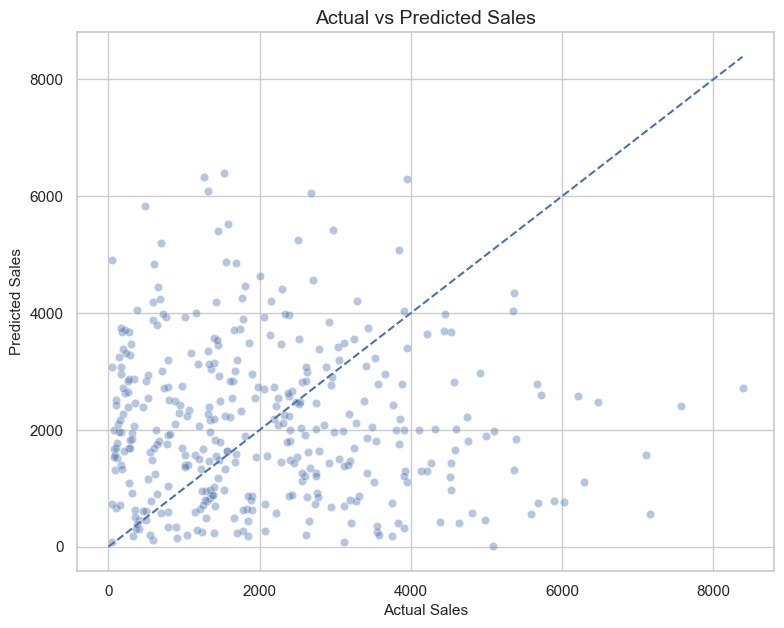

In [125]:
plt.figure(figsize=(9, 7))

sns.scatterplot(
    data=error_analysis,
    x="Actual",
    y="Predicted",
    alpha=0.4
)

max_value = max(
    error_analysis["Actual"].max(),
    error_analysis["Predicted"].max()
)

plt.plot(
    [0, max_value],
    [0, max_value],
    linestyle="--"
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()

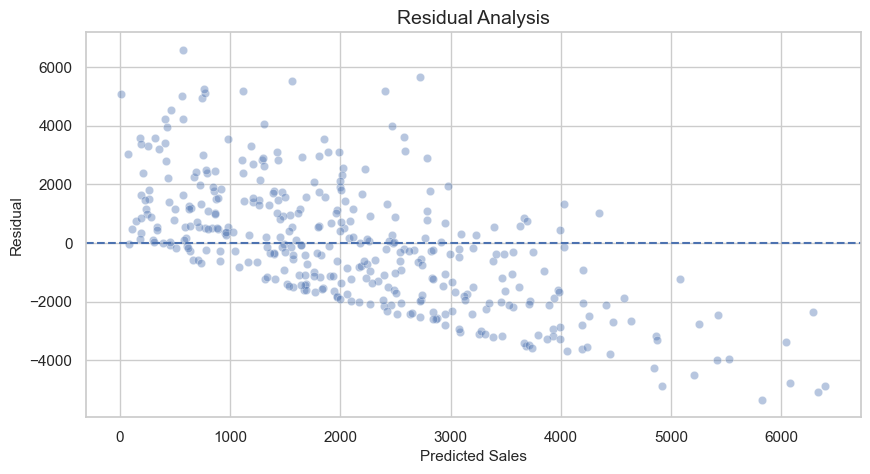

In [126]:
error_analysis["Residual"] = (
    error_analysis["Actual"]
    - error_analysis["Predicted"]
)

plt.figure(figsize=(10, 5))

sns.scatterplot(
    data=error_analysis,
    x="Predicted",
    y="Residual",
    alpha=0.4
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted Sales")
plt.ylabel("Residual")
plt.title("Residual Analysis")

plt.show()

In [127]:
error_analysis["Sales_Bin"] = pd.cut(
    error_analysis["Actual"],
    bins=[-np.inf, 500, 1000, 2000, 3000, 4000, 5000, np.inf],
    labels=[
        "<500",
        "500-1000",
        "1000-2000",
        "2000-3000",
        "3000-4000",
        "4000-5000",
        ">5000"
    ]
)

sales_bin_error = (
    error_analysis
    .groupby("Sales_Bin", observed=False)
    .agg(
        Count=("Actual", "size"),
        Mean_Actual=("Actual", "mean"),
        Mean_Predicted=("Predicted", "mean"),
        MAE=("Absolute_Error", "mean"),
        Mean_Residual=("Residual", "mean")
    )
)

sales_bin_error

,Count,Mean_Actual,Mean_Predicted,MAE,Mean_Residual
Sales_Bin,,,,,
<500,64,232.062509,2094.255760,1872.846414,-1862.193251
500-1000,44,711.467827,2181.122587,1601.202356,-1469.654760
1000-2000,98,1472.824333,2177.401936,1247.617773,-704.577603
2000-3000,71,2516.377034,2287.279522,1042.101832,229.097512
3000-4000,50,3501.934892,1994.788055,1752.874683,1507.146837
4000-5000,23,4531.608487,1908.074458,2623.534029,2623.534029
>5000,19,6076.896768,1851.853130,4225.043639,4225.043639


In [128]:
error_analysis["Percentage_Error_Abs"] = (
    np.abs(
        error_analysis["Actual"]
        - error_analysis["Predicted"]
    )
    / np.maximum(
        np.abs(error_analysis["Actual"]),
        1e-6
    )
) * 100

sales_bin_percentage = (
    error_analysis
    .groupby("Sales_Bin", observed=False)
    .agg(
        Count=("Actual", "size"),
        Mean_Percentage_Error=("Percentage_Error_Abs", "mean")
    )
)

sales_bin_percentage

,Count,Mean_Percentage_Error
Sales_Bin,,
<500,64,1251.268506
500-1000,44,234.152988
1000-2000,98,86.224981
2000-3000,71,41.460612
3000-4000,50,49.758083
4000-5000,23,57.586951
>5000,19,68.992201


In [129]:
bias_summary = (
    error_analysis
    .groupby("Sales_Bin", observed=False)
    .agg(
        Mean_Residual=("Residual", "mean"),
        Median_Residual=("Residual", "median")
    )
)

bias_summary

,Mean_Residual,Median_Residual
Sales_Bin,,
<500,-1862.193251,-1817.387093
500-1000,-1469.654760,-1177.121650
1000-2000,-704.577603,-418.420174
2000-3000,229.097512,195.841508
3000-4000,1507.146837,1693.971440
4000-5000,2623.534029,2847.770662
>5000,4225.043639,4937.960882


In [130]:
error_analysis["MRP_Bin"] = pd.qcut(
    error_analysis["Item_MRP"],
    q=5,
    duplicates="drop"
)

mrp_error = (
    error_analysis
    .groupby("MRP_Bin", observed=False)
    .agg(
        Count=("Actual", "size"),
        Mean_Actual=("Actual", "mean"),
        Mean_Predicted=("Predicted", "mean"),
        MAE=("Absolute_Error", "mean"),
        Mean_Residual=("Residual", "mean")
    )
)

mrp_error

,Count,Mean_Actual,Mean_Predicted,MAE,Mean_Residual
MRP_Bin,,,,,
"(32.489000000000004, 82.179]",341,2241.282540,790.073362,1650.929449,1436.584756
"(82.179, 115.529]",341,2200.876802,1545.472676,1373.200407,666.265936
"(115.529, 153.326]",341,1916.343894,2065.077901,1424.988566,-122.893127
"(153.326, 191.211]",341,2004.594339,2625.273302,1727.680514,-777.662782
"(191.211, 266.588]",341,1940.263107,3611.072853,2175.479736,-1757.447806


In [131]:
error_analysis["Visibility_Bin"] = pd.qcut(
    error_analysis["Item_Visibility"],
    q=5,
    duplicates="drop"
)

visibility_error = (
    error_analysis
    .groupby("Visibility_Bin", observed=False)
    .agg(
        Count=("Actual", "size"),
        MAE=("Absolute_Error", "mean"),
        Mean_Residual=("Residual", "mean")
    )
)

visibility_error

,Count,MAE,Mean_Residual
Visibility_Bin,,,
"(-0.001, 0.023]",341,1746.872468,-130.545569
"(0.023, 0.0418]",341,1580.072818,-617.272790
"(0.0418, 0.0667]",341,1692.904035,-85.033234
"(0.0667, 0.106]",341,1412.627211,163.983215
"(0.106, 0.311]",341,1830.166388,240.963087


In [132]:
visibility_outlet_error = (
    error_analysis
    .groupby(
        ["Outlet_Type", "Visibility_Bin"],
        observed=False
    )
    .agg(
        Count=("Actual", "size"),
        MAE=("Absolute_Error", "mean"),
        Mean_Residual=("Residual", "mean"),
        Mean_Actual=("Actual", "mean"),
        Mean_Predicted=("Predicted", "mean")
    )
    .reset_index()
)

visibility_outlet_error

,Outlet_Type,Visibility_Bin,Count,MAE,Mean_Residual,Mean_Actual,Mean_Predicted
0,Grocery Store,"(-0.001, 0.023]",21,1687.034817,1687.034817,2039.079080,345.998108
1,Grocery Store,"(0.023, 0.0418]",28,647.743834,647.743834,912.811800,313.472988
2,Grocery Store,"(0.0418, 0.0667]",44,2170.423941,2168.838032,2492.255850,304.701039
3,Grocery Store,"(0.0667, 0.106]",36,1992.508586,1981.569487,2252.401400,327.889053
4,Grocery Store,"(0.106, 0.311]",95,1432.621857,1234.692857,1652.552589,350.388893
5,Supermarket Type1,"(-0.001, 0.023]",243,1685.648324,-83.749430,2439.142448,2376.853627
6,Supermarket Type1,"(0.023, 0.0418]",239,1378.969286,-245.293744,1752.810972,2163.207442
7,Supermarket Type1,"(0.0418, 0.0667]",233,1529.777986,-109.699345,2009.192342,2304.719511
8,Supermarket Type1,"(0.0667, 0.106]",241,1130.160114,212.455076,2085.441426,2208.410977
9,Supermarket Type1,"(0.106, 0.311]",175,1818.168519,-116.698133,2159.880325,2303.645177


In [133]:
visibility_outlet_error.sort_values(
    "MAE",
    ascending=False
).head(15)

,Outlet_Type,Visibility_Bin,Count,MAE,Mean_Residual,Mean_Actual,Mean_Predicted
19,Supermarket Type3,"(0.106, 0.311]",33,4342.642130,257.533375,3644.189720,3724.631029
17,Supermarket Type3,"(0.0418, 0.0667]",34,2643.045806,-2643.045806,1877.056650,4193.381615
16,Supermarket Type3,"(0.023, 0.0418]",32,2599.328835,-2007.488610,1700.852680,3389.842230
18,Supermarket Type3,"(0.0667, 0.106]",36,2535.852880,-1966.073922,2448.146600,4043.931706
2,Grocery Store,"(0.0418, 0.0667]",44,2170.423941,2168.838032,2492.255850,304.701039
3,Grocery Store,"(0.0667, 0.106]",36,1992.508586,1981.569487,2252.401400,327.889053
15,Supermarket Type3,"(-0.001, 0.023]",39,1966.866710,-1966.866710,1724.422000,3583.367037
10,Supermarket Type2,"(-0.001, 0.023]",38,1964.722952,110.773563,1983.720836,1902.092849
9,Supermarket Type1,"(0.106, 0.311]",175,1818.168519,-116.698133,2159.880325,2303.645177
0,Grocery Store,"(-0.001, 0.023]",21,1687.034817,1687.034817,2039.079080,345.998108


In [134]:
outlet_error

,MAE,RMSE,Mean_Actual,Mean_Predicted,Count
Outlet_Type,,,,,
Supermarket Type3,2693.072876,3079.190427,2136.271863,3789.055207,174
Grocery Store,1686.043428,2208.569119,1951.824405,332.772323,224
Supermarket Type1,1533.337254,1946.562369,2126.432571,2269.625648,1131
Supermarket Type2,1495.090735,1896.929631,1764.510168,1854.679480,176


In [135]:
item_error

,MAE,Mean_Actual,Mean_Predicted,Count
Item_Type,,,,
Breakfast,3393.033431,2817.665600,2139.449388,24
Breads,2362.710080,2519.553650,2085.883513,61
Fruits and Vegetables,1949.312787,2363.209543,2200.082904,230
Meat,1772.461699,2119.047208,2070.374939,100
Health and Hygiene,1759.315842,1852.884411,2046.135894,111
Frozen Foods,1725.778929,2264.702055,2166.373264,175
Baking Goods,1691.010899,2019.325483,1810.623070,139
Snack Foods,1681.845328,1831.859073,2233.827112,229
Others,1628.580968,1973.431200,1922.699355,30


In [136]:
def feature_engineering_v5(df):
    df = df.copy()

    # -----------------------------
    # Basic features we already know
    # -----------------------------

    df["Outlet_Age"] = (
        2026 - df["Outlet_Establishment_Year"]
    )

    df["Item_ID_Category"] = (
        df["Item_Identifier"]
        .astype(str)
        .str[:2]
    )

    df["Item_Visibility_Zero"] = (
        df["Item_Visibility"] == 0
    ).astype(int)

    df["Item_Visibility_Log"] = np.log1p(
        df["Item_Visibility"]
    )

    df["Item_MRP_Log"] = np.log1p(
        df["Item_MRP"]
    )

    # -----------------------------
    # Selected numerical features
    # -----------------------------

    weight_safe = df["Item_Weight"].fillna(
        df["Item_Weight"].median()
    )

    df["MRP_Per_Weight"] = (
        df["Item_MRP"] /
        (weight_safe + 1e-6)
    )

    df["Visibility_Per_MRP"] = (
        df["Item_Visibility"] /
        (df["Item_MRP"] + 1e-6)
    )

    # -----------------------------
    # Targeted outlet interactions
    # -----------------------------

    df["OutletType_OutletSize"] = (
        df["Outlet_Type"].astype(str)
        + "_"
        + df["Outlet_Size"].astype(str)
    )

    df["OutletType_Location"] = (
        df["Outlet_Type"].astype(str)
        + "_"
        + df["Outlet_Location_Type"].astype(str)
    )

    df["OutletType_ItemCategory"] = (
        df["Outlet_Type"].astype(str)
        + "_"
        + df["Item_ID_Category"].astype(str)
    )

    return df

In [137]:
X_train_v5 = feature_engineering_v5(
    clean_data(X_train)
)

X_valid_v5 = feature_engineering_v5(
    clean_data(X_valid)
)

print("Original:", X_train_fe.shape)
print("V5:", X_train_v5.shape)

Original: (6818, 19)
V5: (6818, 21)


In [138]:
categorical_features_v5 = (
    X_train_v5
    .select_dtypes(include=["object"])
    .columns
    .tolist()
)

for col in categorical_features_v5:
    X_train_v5[col] = X_train_v5[col].astype(str)
    X_valid_v5[col] = X_valid_v5[col].astype(str)

In [139]:
catboost_v5 = CatBoostRegressor(
    iterations=990,
    depth=4,
    learning_rate=0.039965,
    l2_leaf_reg=2.80586,
    random_strength=1.15575,
    bagging_temperature=0.50767,
    loss_function="RMSE",
    random_seed=SEED,
    thread_count=1,
    verbose=False
)

catboost_v5.fit(
    X_train_v5,
    y_train,
    cat_features=categorical_features_v5
)

CatBoostRegressor(bagging_temperature=0.50767, depth=4, iterations=990, l2_leaf_reg=2.80586, learning_rate=0.039965, loss_function='RMSE', random_seed=42, random_strength=1.15575, thread_count=1, verbose=False)

In [140]:
v5_train_pred = catboost_v5.predict(
    X_train_v5
)

v5_valid_pred = catboost_v5.predict(
    X_valid_v5
)

v5_train_metrics = evaluate_regression(
    y_train,
    v5_train_pred
)

v5_valid_metrics = evaluate_regression(
    y_valid,
    v5_valid_pred
)

print(
    "Train R²       :",
    round(v5_train_metrics["R2"], 4)
)

print(
    "Validation R²  :",
    round(v5_valid_metrics["R2"], 4)
)

print(
    "Validation MAE :",
    round(v5_valid_metrics["MAE"], 2)
)

print(
    "Validation RMSE:",
    round(v5_valid_metrics["RMSE"], 2)
)

print(
    "Within ±10%    :",
    f"{v5_valid_metrics['Within_10pct']:.2%}"
)

print(
    "Within ±20%    :",
    f"{v5_valid_metrics['Within_20pct']:.2%}"
)

Train R²       : 0.6194
Validation R²  : 0.6103
Validation MAE : 721.33
Validation RMSE: 1029.13
Within ±10%    : 15.19%
Within ±20%    : 33.72%


In [141]:
X_champion_train = X_train_fe.copy()
X_champion_valid = X_valid_fe.copy()

for col in categorical_features:
    X_champion_train[col] = X_champion_train[col].astype(str)
    X_champion_valid[col] = X_champion_valid[col].astype(str)

y_champion_train = y_train.reset_index(drop=True)
y_champion_valid = y_valid.reset_index(drop=True)

In [142]:
def objective_catboost_v2(trial):

    params = {
        "iterations": trial.suggest_int(
            "iterations", 400, 1800
        ),

        "depth": trial.suggest_int(
            "depth", 3, 8
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.08,
            log=True
        ),

        "l2_leaf_reg": trial.suggest_float(
            "l2_leaf_reg",
            1.0,
            30.0,
            log=True
        ),

        "random_strength": trial.suggest_float(
            "random_strength",
            0.0,
            3.0
        ),

        "bagging_temperature": trial.suggest_float(
            "bagging_temperature",
            0.0,
            3.0
        ),

        "border_count": trial.suggest_int(
            "border_count",
            32,
            255
        ),

        "loss_function": "RMSE",
        "random_seed": SEED,
        "thread_count": 1,
        "verbose": False
    }

    scores = []

    for train_idx, valid_idx in cv.split(
        X_champion_train
    ):

        X_fold_train = X_champion_train.iloc[train_idx]
        X_fold_valid = X_champion_train.iloc[valid_idx]

        y_fold_train = y_champion_train.iloc[train_idx]
        y_fold_valid = y_champion_train.iloc[valid_idx]

        model = CatBoostRegressor(**params)

        model.fit(
            X_fold_train,
            y_fold_train,
            cat_features=categorical_features,
            eval_set=(X_fold_valid, y_fold_valid),
            early_stopping_rounds=60,
            verbose=False
        )

        pred = model.predict(
            X_fold_valid
        )

        scores.append(
            r2_score(
                y_fold_valid,
                pred
            )
        )

    return np.mean(scores)

In [143]:
study_v2 = optuna.create_study(
    direction="maximize",
    study_name="BigMart_CatBoost_V2"
)

study_v2.optimize(
    objective_catboost_v2,
    n_trials=40
)

[I 2026-08-31 11:17:45,518] A new study created in memory with name: BigMart_CatBoost_V2
[I 2026-08-31 11:19:17,823] Trial 0 finished with value: 0.5980444328459019 and parameters: {'iterations': 1010, 'depth': 4, 'learning_rate': 0.012429394101797364, 'l2_leaf_reg': 2.4415762007566966, 'random_strength': 0.6327114706284167, 'bagging_temperature': 0.3950369899602343, 'border_count': 137}. Best is trial 0 with value: 0.5980444328459019.
[I 2026-08-31 11:20:16,358] Trial 1 finished with value: 0.5971743524895065 and parameters: {'iterations': 1239, 'depth': 5, 'learning_rate': 0.033058755810910286, 'l2_leaf_reg': 4.319223886231267, 'random_strength': 1.280430235350111, 'bagging_temperature': 0.10970171757094138, 'border_count': 98}. Best is trial 0 with value: 0.5980444328459019.
[I 2026-08-31 11:21:23,780] Trial 2 finished with value: 0.5952524123019726 and parameters: {'iterations': 1705, 'depth': 8, 'learning_rate': 0.04675423669618878, 'l2_leaf_reg': 1.1603391557875669, 'random_stren

In [144]:
print("Best CV R²:")
print(round(study_v2.best_value, 6))

print("\nBest Parameters:")5m 

for key, value in study_v2.best_params.items():
    print(f"{key}: {value}")

Best CV R²:
0.598627

Best Parameters:
iterations: 1545
depth: 4
learning_rate: 0.02814589659609916
l2_leaf_reg: 1.7306369862391742
random_strength: 0.5443859731749051
bagging_temperature: 2.0182135287967764
border_count: 255


best_catboost = CatBoostRegressor(
    iterations=990,
    depth=4,
    learning_rate=0.039965,
    l2_leaf_reg=2.80586,
    random_strength=1.15575,
    bagging_temperature=0.50767,
    loss_function="RMSE",
    random_seed=SEED,
    thread_count=1,
    verbose=False
)

best_catboost.fit(
    X_champion_train,
    y_champion_train,
    cat_features=categorical_features
)

In [145]:
best_catboost = CatBoostRegressor(
    iterations=990,
    depth=4,
    learning_rate=0.039965,
    l2_leaf_reg=2.80586,
    random_strength=1.15575,
    bagging_temperature=0.50767,
    loss_function="RMSE",
    random_seed=SEED,
    thread_count=1,
    verbose=False
)

best_catboost.fit(
    X_champion_train,
    y_champion_train,
    cat_features=categorical_features
)

print("Best CatBoost model trained successfully.")

Best CatBoost model trained successfully.


In [146]:
best_train_pred = best_catboost.predict(
    X_champion_train
)

best_valid_pred = best_catboost.predict(
    X_champion_valid
)

best_train_metrics = evaluate_regression(
    y_champion_train,
    best_train_pred
)

best_valid_metrics = evaluate_regression(
    y_champion_valid,
    best_valid_pred
)

print("Train R²       :", round(best_train_metrics["R2"], 4))
print("Validation R²  :", round(best_valid_metrics["R2"], 4))
print("Validation MAE :", round(best_valid_metrics["MAE"], 2))
print("Validation RMSE:", round(best_valid_metrics["RMSE"], 2))
print("Within ±10%    :", f"{best_valid_metrics['Within_10pct']:.2%}")
print("Within ±20%    :", f"{best_valid_metrics['Within_20pct']:.2%}")

Train R²       : 0.6261
Validation R²  : 0.6142
Validation MAE : 717.28
Validation RMSE: 1023.99
Within ±10%    : 15.72%
Within ±20%    : 34.37%


In [147]:
cat_pred = catboost_model.predict(X_valid_cb)

xgb_pred = xgb_model.predict(X_valid_fe)

lgbm_pred = lgbm_model.predict(X_valid_fe)

In [148]:
print("CatBoost :", r2_score(y_valid, cat_pred))
print("XGBoost  :", r2_score(y_valid, xgb_pred))
print("LightGBM :", r2_score(y_valid, lgbm_pred))

CatBoost : 0.6163945239718812
XGBoost  : 0.6088619395886152
LightGBM : 0.6036315072320692


In [149]:
ensemble_results = []

weights_list = [
    (0.6, 0.2, 0.2),
    (0.5, 0.3, 0.2),
    (0.5, 0.2, 0.3),
    (0.7, 0.15, 0.15),
    (0.4, 0.3, 0.3)
]

for cat_w, xgb_w, lgbm_w in weights_list:

    ensemble_pred = (
        cat_w * cat_pred
        + xgb_w * xgb_pred
        + lgbm_w * lgbm_pred
    )

    metrics = evaluate_regression(
        y_valid,
        ensemble_pred
    )

    ensemble_results.append({
        "CatBoost_Weight": cat_w,
        "XGBoost_Weight": xgb_w,
        "LightGBM_Weight": lgbm_w,
        "R2": metrics["R2"],
        "MAE": metrics["MAE"],
        "RMSE": metrics["RMSE"],
        "Within_10pct": metrics["Within_10pct"],
        "Within_20pct": metrics["Within_20pct"]
    })

ensemble_df = (
    pd.DataFrame(ensemble_results)
    .sort_values("R2", ascending=False)
    .reset_index(drop=True)
)

ensemble_df

,CatBoost_Weight,XGBoost_Weight,LightGBM_Weight,R2,MAE,RMSE,Within_10pct,Within_20pct
0,0.7,0.15,0.15,0.615206,715.067098,1022.672704,0.162463,0.350147
1,0.6,0.20,0.20,0.614547,715.237071,1023.547847,0.160704,0.350147
2,0.5,0.30,0.20,0.613877,715.639629,1024.436550,0.163636,0.351906
3,0.5,0.20,0.30,0.613604,715.377809,1024.798372,0.162463,0.354252
4,0.4,0.30,0.30,0.612835,715.919089,1025.817794,0.163050,0.353079


In [150]:
prediction_df = pd.DataFrame({
    "CatBoost": cat_pred,
    "XGBoost": xgb_pred,
    "LightGBM": lgbm_pred
})

prediction_corr = prediction_df.corr()

prediction_corr

,CatBoost,XGBoost,LightGBM
CatBoost,1.000000,0.995684,0.991873
XGBoost,0.995684,1.000000,0.995162
LightGBM,0.991873,0.995162,1.000000


In [151]:
residual_df = pd.DataFrame({
    "CatBoost": y_valid.reset_index(drop=True) - cat_pred,
    "XGBoost": y_valid.reset_index(drop=True) - xgb_pred,
    "LightGBM": y_valid.reset_index(drop=True) - lgbm_pred
})

residual_corr = residual_df.corr()

residual_corr

,CatBoost,XGBoost,LightGBM
CatBoost,1.000000,0.992755,0.986463
XGBoost,0.992755,1.000000,0.991941
LightGBM,0.986463,0.991941,1.000000


In [152]:
individual_results = pd.DataFrame({
    "Model": [
        "CatBoost",
        "XGBoost",
        "LightGBM"
    ],
    "R2": [
        r2_score(y_valid, cat_pred),
        r2_score(y_valid, xgb_pred),
        r2_score(y_valid, lgbm_pred)
    ],
    "MAE": [
        mean_absolute_error(y_valid, cat_pred),
        mean_absolute_error(y_valid, xgb_pred),
        mean_absolute_error(y_valid, lgbm_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_valid, cat_pred)),
        np.sqrt(mean_squared_error(y_valid, xgb_pred)),
        np.sqrt(mean_squared_error(y_valid, lgbm_pred))
    ]
})

individual_results

,Model,R2,MAE,RMSE
0,CatBoost,0.616395,715.414658,1021.091671
1,XGBoost,0.608862,719.671462,1031.068155
2,LightGBM,0.603632,721.119693,1037.939159


# 🚀 Final Advanced Modeling Pipeline

This section consolidates the best-performing preprocessing,
feature engineering, model selection, and evaluation steps into
a reproducible machine learning pipeline.

The goal is to maximize generalization performance while
maintaining a leakage-free and deployment-ready workflow.

# 🏆 Final Model Development

After extensive experimentation, CatBoost currently provides
the strongest validation performance among the tested models.

The following section rebuilds the final modeling pipeline
from clean source data and evaluates candidate models using
a consistent and leakage-aware methodology.

In [153]:
# Reload the original BigMart datasets
train_final = pd.read_csv("../data/Train.csv")
test_final = pd.read_csv("../data/Test.csv")

print("Train shape:", train_final.shape)
print("Test shape :", test_final.shape)

Train shape: (8523, 12)
Test shape : (5681, 11)


In [154]:
def clean_categorical_values(df):
    df = df.copy()

    # Standardize Item_Fat_Content
    df["Item_Fat_Content"] = (
        df["Item_Fat_Content"]
        .replace({
            "LF": "Low Fat",
            "low fat": "Low Fat",
            "Low Fat": "Low Fat",
            "reg": "Regular",
            "Regular": "Regular"
        })
    )

    return df

In [155]:
train_final = clean_categorical_values(train_final)
test_final = clean_categorical_values(test_final)

print("Categorical values standardized.")

Categorical values standardized.


In [156]:
TARGET = "Item_Outlet_Sales"

X_final = train_final.drop(
    columns=[TARGET]
)

y_final = train_final[TARGET]

print("Feature shape:", X_final.shape)
print("Target shape :", y_final.shape)

Feature shape: (8523, 11)
Target shape : (8523,)


In [157]:
from sklearn.model_selection import train_test_split

X_dev, X_holdout, y_dev, y_holdout = train_test_split(
    X_final,
    y_final,
    test_size=0.20,
    random_state=SEED
)

print("Development set :", X_dev.shape)
print("Holdout set     :", X_holdout.shape)

Development set : (6818, 11)
Holdout set     : (1705, 11)


In [158]:
def final_feature_engineering(df):
    df = df.copy()

    # ----------------------------------
    # Outlet age
    # ----------------------------------
    df["Outlet_Age"] = (
        2026 - df["Outlet_Establishment_Year"]
    )

    # ----------------------------------
    # Item identifier category
    # FD / DR / NC
    # ----------------------------------
    df["Item_ID_Category"] = (
        df["Item_Identifier"]
        .astype(str)
        .str[:2]
    )

    # ----------------------------------
    # Visibility features
    # ----------------------------------
    df["Item_Visibility_Zero"] = (
        df["Item_Visibility"] == 0
    ).astype(int)

    df["Item_Visibility_Log"] = np.log1p(
        df["Item_Visibility"]
    )

    # ----------------------------------
    # MRP transformation
    # ----------------------------------
    df["Item_MRP_Log"] = np.log1p(
        df["Item_MRP"]
    )

    return df

In [159]:
X_dev = final_feature_engineering(
    X_dev
)

X_holdout = final_feature_engineering(
    X_holdout
)

X_test_final = final_feature_engineering(
    test_final
)

print("Development:", X_dev.shape)
print("Holdout    :", X_holdout.shape)
print("Test       :", X_test_final.shape)

Development: (6818, 16)
Holdout    : (1705, 16)
Test       : (5681, 16)


In [160]:
numeric_features_final = (
    X_dev
    .select_dtypes(
        include=["int64", "float64"]
    )
    .columns
    .tolist()
)

categorical_features_final = (
    X_dev
    .select_dtypes(
        include=["object"]
    )
    .columns
    .tolist()
)

print("Numeric features:")
print(numeric_features_final)

print("\nCategorical features:")
print(categorical_features_final)

Numeric features:
['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Establishment_Year', 'Outlet_Age', 'Item_Visibility_Zero', 'Item_Visibility_Log', 'Item_MRP_Log']

Categorical features:
['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Outlet_Identifier', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type', 'Item_ID_Category']


In [161]:
X_dev_cb = X_dev.copy()
X_holdout_cb = X_holdout.copy()
X_test_cb = X_test_final.copy()

for col in categorical_features_final:

    X_dev_cb[col] = (
        X_dev_cb[col]
        .astype(str)
    )

    X_holdout_cb[col] = (
        X_holdout_cb[col]
        .astype(str)
    )

    X_test_cb[col] = (
        X_test_cb[col]
        .astype(str)
    )

print("CatBoost datasets prepared.")

CatBoost datasets prepared.


In [162]:
final_baseline_catboost = CatBoostRegressor(
    iterations=800,
    learning_rate=0.03,
    depth=6,
    l2_leaf_reg=5,
    loss_function="RMSE",
    random_seed=SEED,
    thread_count=1,
    verbose=False
)

final_baseline_catboost.fit(
    X_dev_cb,
    y_dev.reset_index(drop=True),
    cat_features=categorical_features_final
)

holdout_pred = final_baseline_catboost.predict(
    X_holdout_cb
)

In [163]:
final_baseline_metrics = evaluate_regression(
    y_holdout.reset_index(drop=True),
    holdout_pred
)

print("Validation R²       :", round(final_baseline_metrics["R2"], 4))
print("Validation MAE      :", round(final_baseline_metrics["MAE"], 2))
print("Validation RMSE     :", round(final_baseline_metrics["RMSE"], 2))
print(
    "Within ±10%         :",
    f"{final_baseline_metrics['Within_10pct']:.2%}"
)
print(
    "Within ±20%         :",
    f"{final_baseline_metrics['Within_20pct']:.2%}"
)

Validation R²       : 0.6174
Validation MAE      : 713.94
Validation RMSE     : 1019.76
Within ±10%         : 16.13%
Within ±20%         : 34.90%


In [164]:
numeric_transformer_final = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)

categorical_transformer_final = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

xgb_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer_final,
            numeric_features_final
        ),
        (
            "cat",
            categorical_transformer_final,
            categorical_features_final
        )
    ]
)

In [165]:
xgb_final = Pipeline(
    steps=[
        (
            "preprocessor",
            xgb_preprocessor
        ),
        (
            "model",
            XGBRegressor(
                n_estimators=500,
                learning_rate=0.03,
                max_depth=4,
                min_child_weight=5,
                subsample=0.8,
                colsample_bytree=0.8,
                reg_alpha=0.1,
                reg_lambda=5.0,
                objective="reg:squarederror",
                random_state=SEED,
                n_jobs=1
            )
        )
    ]
)

xgb_final.fit(
    X_dev,
    y_dev.reset_index(drop=True)
)

xgb_holdout_pred = xgb_final.predict(
    X_holdout
)

In [166]:
xgb_final_metrics = evaluate_regression(
    y_holdout.reset_index(drop=True),
    xgb_holdout_pred
)

print("XGBoost R²       :", round(xgb_final_metrics["R2"], 4))
print("XGBoost MAE      :", round(xgb_final_metrics["MAE"], 2))
print("XGBoost RMSE     :", round(xgb_final_metrics["RMSE"], 2))
print(
    "Within ±10%      :",
    f"{xgb_final_metrics['Within_10pct']:.2%}"
)
print(
    "Within ±20%      :",
    f"{xgb_final_metrics['Within_20pct']:.2%}"
)

XGBoost R²       : 0.6115
XGBoost MAE      : 717.96
XGBoost RMSE     : 1027.59
Within ±10%      : 16.95%
Within ±20%      : 34.43%


In [167]:
lgbm_final = Pipeline(
    steps=[
        (
            "preprocessor",
            xgb_preprocessor
        ),
        (
            "model",
            LGBMRegressor(
                n_estimators=500,
                learning_rate=0.03,
                max_depth=5,
                num_leaves=31,
                min_child_samples=30,
                subsample=0.8,
                colsample_bytree=0.8,
                reg_alpha=0.1,
                reg_lambda=5.0,
                random_state=SEED,
                n_jobs=1,
                verbosity=-1
            )
        )
    ]
)

lgbm_final.fit(
    X_dev,
    y_dev.reset_index(drop=True)
)

lgbm_holdout_pred = lgbm_final.predict(
    X_holdout
)

In [168]:
lgbm_final_metrics = evaluate_regression(
    y_holdout.reset_index(drop=True),
    lgbm_holdout_pred
)

print("LightGBM R²       :", round(lgbm_final_metrics["R2"], 4))
print("LightGBM MAE      :", round(lgbm_final_metrics["MAE"], 2))
print("LightGBM RMSE     :", round(lgbm_final_metrics["RMSE"], 2))
print(
    "Within ±10%       :",
    f"{lgbm_final_metrics['Within_10pct']:.2%}"
)
print(
    "Within ±20%       :",
    f"{lgbm_final_metrics['Within_20pct']:.2%}"
)

LightGBM R²       : 0.6043
LightGBM MAE      : 722.19
LightGBM RMSE     : 1037.03
Within ±10%       : 16.89%
Within ±20%       : 34.25%


In [169]:
final_model_comparison = pd.DataFrame({
    "Model": [
        "CatBoost",
        "XGBoost",
        "LightGBM"
    ],
    "R2": [
        final_baseline_metrics["R2"],
        xgb_final_metrics["R2"],
        lgbm_final_metrics["R2"]
    ],
    "MAE": [
        final_baseline_metrics["MAE"],
        xgb_final_metrics["MAE"],
        lgbm_final_metrics["MAE"]
    ],
    "RMSE": [
        final_baseline_metrics["RMSE"],
        xgb_final_metrics["RMSE"],
        lgbm_final_metrics["RMSE"]
    ],
    "Within_10pct": [
        final_baseline_metrics["Within_10pct"],
        xgb_final_metrics["Within_10pct"],
        lgbm_final_metrics["Within_10pct"]
    ],
    "Within_20pct": [
        final_baseline_metrics["Within_20pct"],
        xgb_final_metrics["Within_20pct"],
        lgbm_final_metrics["Within_20pct"]
    ]
})

final_model_comparison.sort_values(
    "R2",
    ascending=False
).reset_index(drop=True)

,Model,R2,MAE,RMSE,Within_10pct,Within_20pct
0,CatBoost,0.617398,713.937092,1019.755275,0.161290,0.348974
1,XGBoost,0.611495,717.955483,1027.592331,0.169501,0.344282
2,LightGBM,0.604325,722.187475,1037.030691,0.168915,0.342522


# 🔬 Rigorous Final Model Validation

All previous experiments were used for model exploration and selection.

To obtain a more reliable estimate of generalization performance,
the final model will be evaluated using nested cross-validation.

The outer folds provide an unbiased performance estimate,
while the inner process is used for model selection.

The final production model will subsequently be retrained
on the complete labeled training dataset and used to generate
predictions for the unseen Test dataset.

In [170]:
from sklearn.model_selection import KFold

outer_cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

print("Outer 5-fold cross-validation created.")

Outer 5-fold cross-validation created.


In [171]:
def regression_metrics(y_true, y_pred):

    r2 = r2_score(y_true, y_pred)

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    percentage_error = (
        np.abs(y_true - y_pred)
        /
        np.maximum(
            np.abs(y_true),
            1e-6
        )
    )

    within_10 = np.mean(
        percentage_error <= 0.10
    )

    within_20 = np.mean(
        percentage_error <= 0.20
    )

    return {
        "R2": r2,
        "MAE": mae,
        "RMSE": rmse,
        "Within_10pct": within_10,
        "Within_20pct": within_20
    }

In [172]:
X_all = train_final.drop(
    columns=[TARGET]
).copy()

y_all = train_final[TARGET].copy()

X_all = final_feature_engineering(
    X_all
)

print("Final feature matrix:", X_all.shape)
print("Target:", y_all.shape)

Final feature matrix: (8523, 16)
Target: (8523,)


In [173]:
final_cat_features = (
    X_all
    .select_dtypes(
        include=["object"]
    )
    .columns
    .tolist()
)

print("Categorical features:")
print(final_cat_features)

Categorical features:
['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Outlet_Identifier', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type', 'Item_ID_Category']


In [174]:
X_all_cb = X_all.copy()

for col in final_cat_features:

    X_all_cb[col] = (
        X_all_cb[col]
        .astype(str)
    )

print("Categorical columns prepared.")

Categorical columns prepared.


In [175]:
outer_scores = []

oof_predictions = np.zeros(
    len(X_all_cb)
)

for fold, (train_idx, valid_idx) in enumerate(
    outer_cv.split(X_all_cb),
    start=1
):

    print(f"\n{'=' * 60}")
    print(f"Outer Fold {fold}")
    print(f"{'=' * 60}")

    X_fold_train = X_all_cb.iloc[train_idx]
    X_fold_valid = X_all_cb.iloc[valid_idx]

    y_fold_train = y_all.iloc[train_idx]
    y_fold_valid = y_all.iloc[valid_idx]

    model = CatBoostRegressor(
        iterations=800,
        learning_rate=0.03,
        depth=6,
        l2_leaf_reg=5,
        loss_function="RMSE",
        random_seed=SEED,
        thread_count=1,
        verbose=False
    )

    model.fit(
        X_fold_train,
        y_fold_train,
        cat_features=final_cat_features
    )

    fold_pred = model.predict(
        X_fold_valid
    )

    oof_predictions[valid_idx] = fold_pred

    fold_metrics = regression_metrics(
        y_fold_valid,
        fold_pred
    )

    outer_scores.append(
        fold_metrics
    )

    print(
        f"Fold R²: {fold_metrics['R2']:.4f}"
    )

    print(
        f"Fold MAE: {fold_metrics['MAE']:.2f}"
    )

    print(
        f"Fold RMSE: {fold_metrics['RMSE']:.2f}"
    )


Outer Fold 1
Fold R²: 0.6183
Fold MAE: 715.04
Fold RMSE: 1018.51

Outer Fold 2
Fold R²: 0.5960
Fold MAE: 749.18
Fold RMSE: 1077.84

Outer Fold 3
Fold R²: 0.6113
Fold MAE: 759.79
Fold RMSE: 1064.95

Outer Fold 4
Fold R²: 0.5834
Fold MAE: 764.15
Fold RMSE: 1117.37

Outer Fold 5
Fold R²: 0.5878
Fold MAE: 788.90
Fold RMSE: 1117.87


In [176]:
outer_results = pd.DataFrame(
    outer_scores
)

outer_results.index = [
    "Fold 1",
    "Fold 2",
    "Fold 3",
    "Fold 4",
    "Fold 5"
]

outer_results

,R2,MAE,RMSE,Within_10pct,Within_20pct
Fold 1,0.618332,715.035484,1018.509791,0.158358,0.343695
Fold 2,0.596043,749.177949,1077.838573,0.176540,0.352493
Fold 3,0.611345,759.788853,1064.947165,0.168328,0.331378
Fold 4,0.583423,764.151913,1117.371391,0.177230,0.358568
Fold 5,0.587800,788.899636,1117.873703,0.159038,0.328638


In [177]:
print("Mean R²  :", round(
    outer_results["R2"].mean(),
    4
))

print("Std R²   :", round(
    outer_results["R2"].std(),
    4
))

print("Mean MAE :", round(
    outer_results["MAE"].mean(),
    2
))

print("Mean RMSE:", round(
    outer_results["RMSE"].mean(),
    2
))

print(
    "Mean ±10%:",
    f"{outer_results['Within_10pct'].mean():.2%}"
)

print(
    "Mean ±20%:",
    f"{outer_results['Within_20pct'].mean():.2%}"
)

Mean R²  : 0.5994
Std R²   : 0.015
Mean MAE : 755.41
Mean RMSE: 1079.31
Mean ±10%: 16.79%
Mean ±20%: 34.30%


In [178]:
oof_metrics = regression_metrics(
    y_all.reset_index(drop=True),
    oof_predictions
)

print("OOF R²       :", round(oof_metrics["R2"], 4))
print("OOF MAE      :", round(oof_metrics["MAE"], 2))
print("OOF RMSE     :", round(oof_metrics["RMSE"], 2))
print(
    "OOF ±10%     :",
    f"{oof_metrics['Within_10pct']:.2%}"
)
print(
    "OOF ±20%     :",
    f"{oof_metrics['Within_20pct']:.2%}"
)

OOF R²       : 0.5995
OOF MAE      : 755.41
OOF RMSE     : 1079.93
OOF ±10%     : 16.79%
OOF ±20%     : 34.30%


In [179]:
oof_residuals = (
    y_all.reset_index(drop=True)
    - oof_predictions
)

print(
    "Mean residual:",
    round(oof_residuals.mean(), 2)
)

print(
    "Median residual:",
    round(np.median(oof_residuals), 2)
)

Mean residual: 3.37
Median residual: -45.14


In [180]:
X_stack = X_all.reset_index(drop=True).copy()
y_stack = y_all.reset_index(drop=True).copy()

print("Stacking feature shape:", X_stack.shape)
print("Stacking target shape :", y_stack.shape)

Stacking feature shape: (8523, 16)
Stacking target shape : (8523,)


In [181]:
X_stack_cb = X_stack.copy()

for col in final_cat_features:
    X_stack_cb[col] = X_stack_cb[col].astype(str)

In [182]:
oof_cat = np.zeros(len(X_stack))
oof_xgb = np.zeros(len(X_stack))
oof_lgbm = np.zeros(len(X_stack))

print("OOF prediction arrays created.")

OOF prediction arrays created.


In [183]:
stack_cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

for fold, (train_idx, valid_idx) in enumerate(
    stack_cv.split(X_stack),
    start=1
):

    print(f"\n{'=' * 60}")
    print(f"Stacking Fold {fold}")
    print(f"{'=' * 60}")

    # ==========================================
    # Split data
    # ==========================================

    X_train_fold = X_stack.iloc[train_idx]
    X_valid_fold = X_stack.iloc[valid_idx]

    y_train_fold = y_stack.iloc[train_idx]
    y_valid_fold = y_stack.iloc[valid_idx]

    # ==========================================
    # CatBoost
    # ==========================================

    X_train_cb = X_stack_cb.iloc[train_idx]
    X_valid_cb = X_stack_cb.iloc[valid_idx]

    cat_model = CatBoostRegressor(
        iterations=800,
        learning_rate=0.03,
        depth=6,
        l2_leaf_reg=5,
        loss_function="RMSE",
        random_seed=SEED,
        thread_count=1,
        verbose=False
    )

    cat_model.fit(
        X_train_cb,
        y_train_fold,
        cat_features=final_cat_features
    )

    oof_cat[valid_idx] = cat_model.predict(
        X_valid_cb
    )

    # ==========================================
    # XGBoost
    # ==========================================

    xgb_model_fold = Pipeline(
        steps=[
            (
                "preprocessor",
                xgb_preprocessor
            ),
            (
                "model",
                XGBRegressor(
                    n_estimators=500,
                    learning_rate=0.03,
                    max_depth=4,
                    min_child_weight=5,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    reg_alpha=0.1,
                    reg_lambda=5.0,
                    objective="reg:squarederror",
                    random_state=SEED,
                    n_jobs=1
                )
            )
        ]
    )

    xgb_model_fold.fit(
        X_train_fold,
        y_train_fold
    )

    oof_xgb[valid_idx] = (
        xgb_model_fold.predict(
            X_valid_fold
        )
    )

    # ==========================================
    # LightGBM
    # ==========================================

    lgbm_model_fold = Pipeline(
        steps=[
            (
                "preprocessor",
                xgb_preprocessor
            ),
            (
                "model",
                LGBMRegressor(
                    n_estimators=500,
                    learning_rate=0.03,
                    max_depth=5,
                    num_leaves=31,
                    min_child_samples=30,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    reg_alpha=0.1,
                    reg_lambda=5.0,
                    random_state=SEED,
                    n_jobs=1,
                    verbosity=-1
                )
            )
        ]
    )

    lgbm_model_fold.fit(
        X_train_fold,
        y_train_fold
    )

    oof_lgbm[valid_idx] = (
        lgbm_model_fold.predict(
            X_valid_fold
        )
    )

    # ==========================================
    # Fold evaluation
    # ==========================================

    print(
        "CatBoost R² :",
        round(
            r2_score(
                y_valid_fold,
                oof_cat[valid_idx]
            ),
            4
        )
    )

    print(
        "XGBoost R²  :",
        round(
            r2_score(
                y_valid_fold,
                oof_xgb[valid_idx]
            ),
            4
        )
    )

    print(
        "LightGBM R² :",
        round(
            r2_score(
                y_valid_fold,
                oof_lgbm[valid_idx]
            ),
            4
        )
    )


Stacking Fold 1
CatBoost R² : 0.6183
XGBoost R²  : 0.6134
LightGBM R² : 0.6043

Stacking Fold 2
CatBoost R² : 0.596
XGBoost R²  : 0.5907
LightGBM R² : 0.5819

Stacking Fold 3
CatBoost R² : 0.6113
XGBoost R²  : 0.6051
LightGBM R² : 0.5958

Stacking Fold 4
CatBoost R² : 0.5834
XGBoost R²  : 0.5827
LightGBM R² : 0.58

Stacking Fold 5
CatBoost R² : 0.5878
XGBoost R²  : 0.5855
LightGBM R² : 0.5774


In [184]:
stack_features = pd.DataFrame({
    "CatBoost": oof_cat,
    "XGBoost": oof_xgb,
    "LightGBM": oof_lgbm
})

stack_features.head()

,CatBoost,XGBoost,LightGBM
0,4360.327434,5439.989258,5097.666347
1,607.046038,612.922119,692.866998
2,2371.623996,2250.226562,2396.760240
3,441.273875,573.649109,706.878125
4,813.604515,861.612305,726.940259


In [185]:
stack_features.corr()

,CatBoost,XGBoost,LightGBM
CatBoost,1.000000,0.994604,0.989887
XGBoost,0.994604,1.000000,0.994761
LightGBM,0.989887,0.994761,1.000000


In [186]:
stack_individual_results = pd.DataFrame({
    "Model": [
        "CatBoost",
        "XGBoost",
        "LightGBM"
    ],
    "OOF_R2": [
        r2_score(y_stack, oof_cat),
        r2_score(y_stack, oof_xgb),
        r2_score(y_stack, oof_lgbm)
    ],
    "OOF_MAE": [
        mean_absolute_error(y_stack, oof_cat),
        mean_absolute_error(y_stack, oof_xgb),
        mean_absolute_error(y_stack, oof_lgbm)
    ],
    "OOF_RMSE": [
        np.sqrt(mean_squared_error(y_stack, oof_cat)),
        np.sqrt(mean_squared_error(y_stack, oof_xgb)),
        np.sqrt(mean_squared_error(y_stack, oof_lgbm))
    ]
})

stack_individual_results

,Model,OOF_R2,OOF_MAE,OOF_RMSE
0,CatBoost,0.599473,755.405812,1079.932770
1,XGBoost,0.595615,758.253684,1085.120600
2,LightGBM,0.588072,764.455521,1095.194497


In [187]:
from sklearn.linear_model import Ridge

meta_model = Ridge(
    alpha=10.0
)

meta_model.fit(
    stack_features,
    y_stack
)

print("Meta-model trained.")

Meta-model trained.


In [188]:
stack_oof_pred = meta_model.predict(
    stack_features
)

stack_oof_metrics = regression_metrics(
    y_stack,
    stack_oof_pred
)

print("Stacking OOF R²       :", round(stack_oof_metrics["R2"], 4))
print("Stacking OOF MAE      :", round(stack_oof_metrics["MAE"], 2))
print("Stacking OOF RMSE     :", round(stack_oof_metrics["RMSE"], 2))
print(
    "Stacking OOF ±10%     :",
    f"{stack_oof_metrics['Within_10pct']:.2%}"
)
print(
    "Stacking OOF ±20%     :",
    f"{stack_oof_metrics['Within_20pct']:.2%}"
)

Stacking OOF R²       : 0.5998
Stacking OOF MAE      : 754.99
Stacking OOF RMSE     : 1079.46
Stacking OOF ±10%     : 16.75%
Stacking OOF ±20%     : 34.48%


In [189]:
meta_weights = pd.DataFrame({
    "Base_Model": [
        "CatBoost",
        "XGBoost",
        "LightGBM"
    ],
    "Weight": meta_model.coef_
})

meta_weights

,Base_Model,Weight
0,CatBoost,0.804042
1,XGBoost,0.311531
2,LightGBM,-0.113354


# 🔗 Rigorous Stacking Evaluation

A stacking ensemble is evaluated using leakage-safe out-of-fold
predictions on the development dataset.

The meta-model is trained only on out-of-fold predictions from
the base models and is evaluated on the previously unseen holdout
dataset.

In [190]:
X_stack_dev = X_dev.reset_index(drop=True).copy()
y_stack_dev = y_dev.reset_index(drop=True).copy()

X_stack_holdout = X_holdout.reset_index(drop=True).copy()
y_stack_holdout = y_holdout.reset_index(drop=True).copy()

print("Development:", X_stack_dev.shape)
print("Holdout    :", X_stack_holdout.shape)

Development: (6818, 16)
Holdout    : (1705, 16)


In [191]:
X_stack_dev_cb = X_stack_dev.copy()
X_stack_holdout_cb = X_stack_holdout.copy()

for col in categorical_features_final:
    X_stack_dev_cb[col] = X_stack_dev_cb[col].astype(str)
    X_stack_holdout_cb[col] = X_stack_holdout_cb[col].astype(str)

print("CatBoost data prepared.")

CatBoost data prepared.


In [208]:
oof_cat = np.zeros(len(X_stack_dev))
oof_xgb = np.zeros(len(X_stack_dev))
oof_lgbm = np.zeros(len(X_stack_dev))

stack_cv = KFold(
    n_splits=3,
    shuffle=True,
    random_state=SEED
)

print("3-fold stacking CV created.")

3-fold stacking CV created.


In [209]:
for fold, (train_idx, valid_idx) in enumerate(
    stack_cv.split(X_stack_dev),
    start=1
):

    print(f"\n{'=' * 60}")
    print(f"Stacking Fold {fold}")
    print(f"{'=' * 60}")

    X_fold_train = X_stack_dev.iloc[train_idx]
    X_fold_valid = X_stack_dev.iloc[valid_idx]

    y_fold_train = y_stack_dev.iloc[train_idx]
    y_fold_valid = y_stack_dev.iloc[valid_idx]

    # ==================================================
    # 1. CatBoost
    # ==================================================

    X_fold_train_cb = X_stack_dev_cb.iloc[train_idx]
    X_fold_valid_cb = X_stack_dev_cb.iloc[valid_idx]

    cat_model = CatBoostRegressor(
        iterations=800,
        learning_rate=0.03,
        depth=6,
        l2_leaf_reg=5,
        loss_function="RMSE",
        random_seed=SEED,
        thread_count=1,
        verbose=False
    )

    cat_model.fit(
        X_fold_train_cb,
        y_fold_train,
        cat_features=categorical_features_final
    )

    oof_cat[valid_idx] = cat_model.predict(
        X_fold_valid_cb
    )

    # ==================================================
    # 2. XGBoost
    # ==================================================

    xgb_fold = Pipeline(
        steps=[
            (
                "preprocessor",
                xgb_preprocessor
            ),
            (
                "model",
                XGBRegressor(
                    n_estimators=500,
                    learning_rate=0.03,
                    max_depth=4,
                    min_child_weight=5,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    reg_alpha=0.1,
                    reg_lambda=5.0,
                    objective="reg:squarederror",
                    random_state=SEED,
                    n_jobs=1
                )
            )
        ]
    )

    xgb_fold.fit(
        X_fold_train,
        y_fold_train
    )

    oof_xgb[valid_idx] = xgb_fold.predict(
        X_fold_valid
    )

    # ==================================================
    # 3. LightGBM
    # ==================================================

    lgbm_fold = Pipeline(
        steps=[
            (
                "preprocessor",
                xgb_preprocessor
            ),
            (
                "model",
                LGBMRegressor(
                    n_estimators=500,
                    learning_rate=0.03,
                    max_depth=5,
                    num_leaves=31,
                    min_child_samples=30,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    reg_alpha=0.1,
                    reg_lambda=5.0,
                    random_state=SEED,
                    n_jobs=1,
                    verbosity=-1
                )
            )
        ]
    )

    lgbm_fold.fit(
        X_fold_train,
        y_fold_train
    )

    oof_lgbm[valid_idx] = lgbm_fold.predict(
        X_fold_valid
    )

    # ==================================================
    # Fold scores
    # ==================================================

    print(
        "CatBoost R² :",
        round(
            r2_score(
                y_fold_valid,
                oof_cat[valid_idx]
            ),
            4
        )
    )

    print(
        "XGBoost R²  :",
        round(
            r2_score(
                y_fold_valid,
                oof_xgb[valid_idx]
            ),
            4
        )
    )

    print(
        "LightGBM R² :",
        round(
            r2_score(
                y_fold_valid,
                oof_lgbm[valid_idx]
            ),
            4
        )
    )


Stacking Fold 1
CatBoost R² : 0.5911
XGBoost R²  : 0.5828
LightGBM R² : 0.5804

Stacking Fold 2
CatBoost R² : 0.5897
XGBoost R²  : 0.5794
LightGBM R² : 0.5815

Stacking Fold 3
CatBoost R² : 0.5988
XGBoost R²  : 0.5894
LightGBM R² : 0.5909


In [210]:
stack_oof = pd.DataFrame({
    "CatBoost": oof_cat,
    "XGBoost": oof_xgb,
    "LightGBM": oof_lgbm
})

stack_oof.head()

,CatBoost,XGBoost,LightGBM
0,2957.662465,3119.364014,3301.023760
1,2790.561703,2902.479980,2907.914805
2,1774.855718,1775.247437,1751.156392
3,685.092272,543.333435,469.951087
4,2296.913594,2334.441650,2336.262836


In [211]:
stack_oof_comparison = pd.DataFrame({
    "Model": [
        "CatBoost",
        "XGBoost",
        "LightGBM"
    ],
    "OOF_R2": [
        r2_score(y_stack_dev, oof_cat),
        r2_score(y_stack_dev, oof_xgb),
        r2_score(y_stack_dev, oof_lgbm)
    ],
    "OOF_MAE": [
        mean_absolute_error(y_stack_dev, oof_cat),
        mean_absolute_error(y_stack_dev, oof_xgb),
        mean_absolute_error(y_stack_dev, oof_lgbm)
    ],
    "OOF_RMSE": [
        np.sqrt(mean_squared_error(y_stack_dev, oof_cat)),
        np.sqrt(mean_squared_error(y_stack_dev, oof_xgb)),
        np.sqrt(mean_squared_error(y_stack_dev, oof_lgbm))
    ]
})

stack_oof_comparison.sort_values(
    "OOF_R2",
    ascending=False
).reset_index(drop=True)

,Model,OOF_R2,OOF_MAE,OOF_RMSE
0,CatBoost,0.593722,769.345105,1096.262591
1,LightGBM,0.584793,780.345877,1108.242741
2,XGBoost,0.584426,778.606056,1108.732924


In [212]:
meta_model = Ridge(
    alpha=10.0
)

meta_model.fit(
    stack_oof,
    y_stack_dev
)

print("Stacking meta-model trained.")

Stacking meta-model trained.


In [213]:
final_stack_cat = CatBoostRegressor(
    iterations=800,
    learning_rate=0.03,
    depth=6,
    l2_leaf_reg=5,
    loss_function="RMSE",
    random_seed=SEED,
    thread_count=1,
    verbose=False
)

final_stack_cat.fit(
    X_stack_dev_cb,
    y_stack_dev,
    cat_features=categorical_features_final
)

CatBoostRegressor(depth=6, iterations=800, l2_leaf_reg=5, learning_rate=0.03, loss_function='RMSE', random_seed=42, thread_count=1, verbose=False)

In [214]:
final_stack_xgb = Pipeline(
    steps=[
        ("preprocessor", xgb_preprocessor),
        (
            "model",
            XGBRegressor(
                n_estimators=500,
                learning_rate=0.03,
                max_depth=4,
                min_child_weight=5,
                subsample=0.8,
                colsample_bytree=0.8,
                reg_alpha=0.1,
                reg_lambda=5.0,
                objective="reg:squarederror",
                random_state=SEED,
                n_jobs=1
            )
        )
    ]
)

final_stack_xgb.fit(
    X_stack_dev,
    y_stack_dev
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Item_Weight',
                                                   'Item_Visibility',
                                                   'Item_MRP',
                                                   'Outlet_Establishment_Year',
                                                   'Outlet_Age',
                                                   'Item_Visibility_Zero',
                                                   'Item_Visibility_Log',
                                                   'Item_MRP_Log']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_freque...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.03,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=4, max_leaves=None, min_child_weight=5,
                              missing=nan, monotone_constraints=None,
                              multi_strategy=None, n_estimators=500, n_jobs=1,
                              num_parallel_tree=None, ...))])

In [215]:
final_stack_lgbm = Pipeline(
    steps=[
        ("preprocessor", xgb_preprocessor),
        (
            "model",
            LGBMRegressor(
                n_estimators=500,
                learning_rate=0.03,
                max_depth=5,
                num_leaves=31,
                min_child_samples=30,
                subsample=0.8,
                colsample_bytree=0.8,
                reg_alpha=0.1,
                reg_lambda=5.0,
                random_state=SEED,
                n_jobs=1,
                verbosity=-1
            )
        )
    ]
)

final_stack_lgbm.fit(
    X_stack_dev,
    y_stack_dev
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Item_Weight',
                                                   'Item_Visibility',
                                                   'Item_MRP',
                                                   'Outlet_Establishment_Year',
                                                   'Outlet_Age',
                                                   'Item_Visibility_Zero',
                                                   'Item_Visibility_Log',
                                                   'Item_MRP_Log']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_freque...
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Item_Identifier',
                                                   'Item_Fat_Content',
                                                   'Item_Type',
                                                   'Outlet_Identifier',
                                                   'Outlet_Size',
                                                   'Outlet_Location_Type',
                                                   'Outlet_Type',
                                                   'Item_ID_Category'])])),
                ('model',
                 LGBMRegressor(colsample_bytree=0.8, learning_rate=0.03,
                               max_depth=5, min_child_samples=30,
                               n_estimators=500, n_jobs=1, random_state=42,
                               reg_alpha=0.1, reg_lambda=5.0, subsample=0.8,
                               verbosity=-1))])

In [216]:
holdout_cat_pred = final_stack_cat.predict(
    X_stack_holdout_cb
)

holdout_xgb_pred = final_stack_xgb.predict(
    X_stack_holdout
)

holdout_lgbm_pred = final_stack_lgbm.predict(
    X_stack_holdout
)

In [217]:
holdout_stack_features = pd.DataFrame({
    "CatBoost": holdout_cat_pred,
    "XGBoost": holdout_xgb_pred,
    "LightGBM": holdout_lgbm_pred
})

stack_holdout_pred = meta_model.predict(
    holdout_stack_features
)

In [218]:
stack_holdout_metrics = regression_metrics(
    y_stack_holdout,
    stack_holdout_pred
)

print("Stacking Holdout R²   :", round(
    stack_holdout_metrics["R2"], 4
))

print("Stacking Holdout MAE  :", round(
    stack_holdout_metrics["MAE"], 2
))

print("Stacking Holdout RMSE :", round(
    stack_holdout_metrics["RMSE"], 2
))

print(
    "Stacking ±10%         :",
    f"{stack_holdout_metrics['Within_10pct']:.2%}"
)

print(
    "Stacking ±20%         :",
    f"{stack_holdout_metrics['Within_20pct']:.2%}"
)

Stacking Holdout R²   : 0.6167
Stacking Holdout MAE  : 713.63
Stacking Holdout RMSE : 1020.63
Stacking ±10%         : 16.72%
Stacking ±20%         : 35.01%


In [219]:
stack_final_comparison = pd.DataFrame({
    "Model": [
        "CatBoost",
        "Stacking"
    ],
    "R2": [
        final_baseline_metrics["R2"],
        stack_holdout_metrics["R2"]
    ],
    "MAE": [
        final_baseline_metrics["MAE"],
        stack_holdout_metrics["MAE"]
    ],
    "RMSE": [
        final_baseline_metrics["RMSE"],
        stack_holdout_metrics["RMSE"]
    ],
    "Within_10pct": [
        final_baseline_metrics["Within_10pct"],
        stack_holdout_metrics["Within_10pct"]
    ],
    "Within_20pct": [
        final_baseline_metrics["Within_20pct"],
        stack_holdout_metrics["Within_20pct"]
    ]
})

stack_final_comparison.sort_values(
    "R2",
    ascending=False
).reset_index(drop=True)

,Model,R2,MAE,RMSE,Within_10pct,Within_20pct
0,CatBoost,0.617398,713.937092,1019.755275,0.161290,0.348974
1,Stacking,0.616740,713.630366,1020.631556,0.167155,0.350147


In [220]:
pd.DataFrame({
    "Base_Model": [
        "CatBoost",
        "XGBoost",
        "LightGBM"
    ],
    "Coefficient": meta_model.coef_
})

,Base_Model,Coefficient
0,CatBoost,0.827139
1,XGBoost,-0.092034
2,LightGBM,0.258258


# 🔍 Explainable AI with SHAP

SHAP (SHapley Additive exPlanations) is used to understand how
individual features contribute to the model's predictions.

The goal is to provide both global model interpretability and
local explanations for individual sales predictions.

In [221]:
%pip install shap


   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]

Note: you may need to restart the kernel to use updated packages.


In [223]:
import shap
import matplotlib.pyplot as plt

print("SHAP loaded successfully.")

SHAP loaded successfully.


In [224]:
final_baseline_catboost

CatBoostRegressor(depth=6, iterations=800, l2_leaf_reg=5, learning_rate=0.03, loss_function='RMSE', random_seed=42, thread_count=1, verbose=False)

In [225]:
X_holdout_cb

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Outlet_Age,Item_ID_Category,Item_Visibility_Zero,Item_Visibility_Log,Item_MRP_Log
7503,FDI28,14.300,Low Fat,0.026300,Frozen Foods,79.4302,OUT013,1987,High,Tier 3,Supermarket Type1,39,FD,0,0.025960,4.387390
2957,NCM17,7.930,Low Fat,0.071136,Health and Hygiene,42.7086,OUT046,1997,Small,Tier 1,Supermarket Type1,29,NC,0,0.068720,3.777545
7031,FDC14,14.500,Regular,0.041313,Canned,42.0454,OUT049,1999,Medium,Tier 1,Supermarket Type1,27,FD,0,0.040483,3.762255
1084,DRC36,NaN,Regular,0.044767,Soft Drinks,173.7054,OUT027,1985,Medium,Tier 3,Supermarket Type3,41,DR,0,0.043794,5.163101
856,FDS27,10.195,Regular,0.012456,Meat,197.5110,OUT035,2004,Small,Tier 2,Supermarket Type1,22,FD,0,0.012379,5.290845
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7205,FDJ34,11.800,Regular,0.093656,Snack Foods,127.1704,OUT046,1997,Small,Tier 1,Supermarket Type1,29,FD,0,0.089526,4.853361
3257,FDS55,7.020,Low Fat,0.000000,Fruits and Vegetables,148.1734,OUT018,2009,Medium,Tier 3,Supermarket Type2,17,FD,1,0.000000,5.005109
6346,FDC14,14.500,Regular,0.041215,Canned,42.0454,OUT013,1987,High,Tier 3,Supermarket Type1,39,FD,0,0.040388,3.762255
6318,FDY12,9.800,Regular,0.141184,Baking Goods,50.5008,OUT018,2009,Medium,Tier 3,Supermarket Type2,17,FD,0,0.132066,3.941597


In [226]:
# Use a sample to make SHAP faster
SHAP_SAMPLE_SIZE = min(1000, len(X_holdout_cb))

X_shap = X_holdout_cb.sample(
    SHAP_SAMPLE_SIZE,
    random_state=SEED
).copy()

print("SHAP sample shape:", X_shap.shape)

SHAP sample shape: (1000, 16)


In [227]:
explainer = shap.TreeExplainer(
    final_baseline_catboost
)

print("SHAP TreeExplainer created.")

SHAP TreeExplainer created.


In [228]:
shap_values = explainer(
    X_shap
)

print("SHAP values calculated.")

SHAP values calculated.


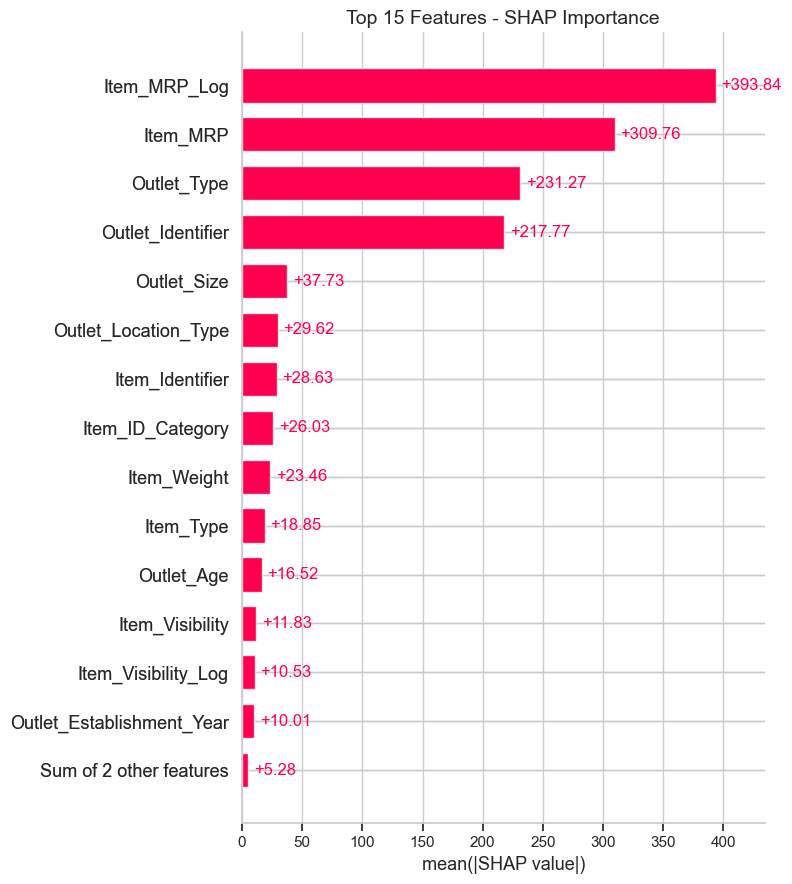

In [229]:
plt.figure(figsize=(10, 7))

shap.plots.bar(
    shap_values,
    max_display=15,
    show=False
)

plt.title(
    "Top 15 Features - SHAP Importance"
)

plt.tight_layout()
plt.show()

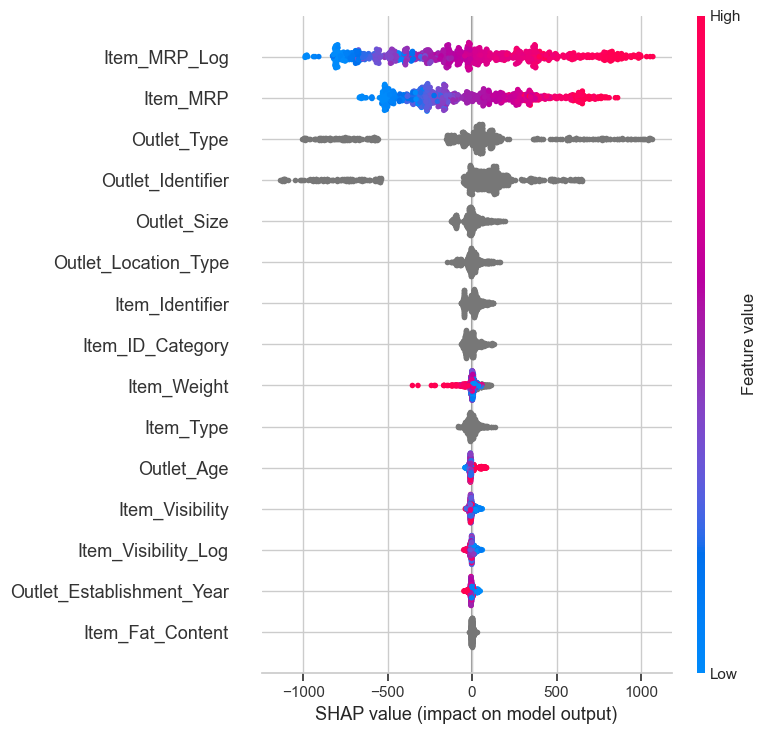

In [230]:
plt.figure(figsize=(10, 8))

shap.summary_plot(
    shap_values.values,
    X_shap,
    max_display=15,
    show=False
)

plt.tight_layout()
plt.show()

In [231]:
print(
    "Item_MRP" in X_shap.columns
)

True


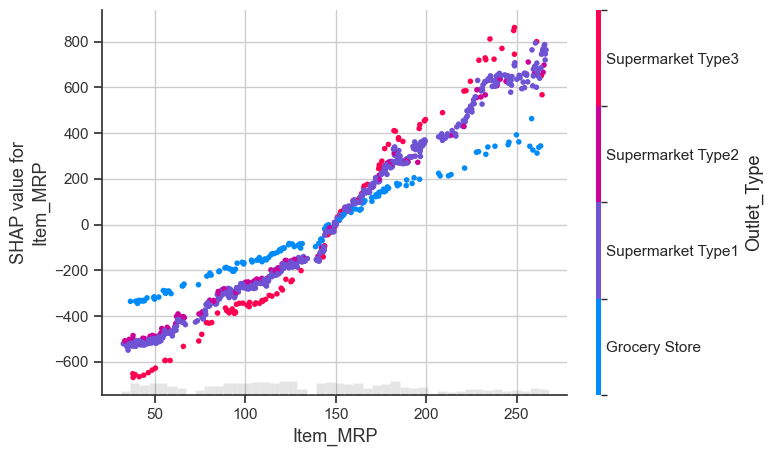

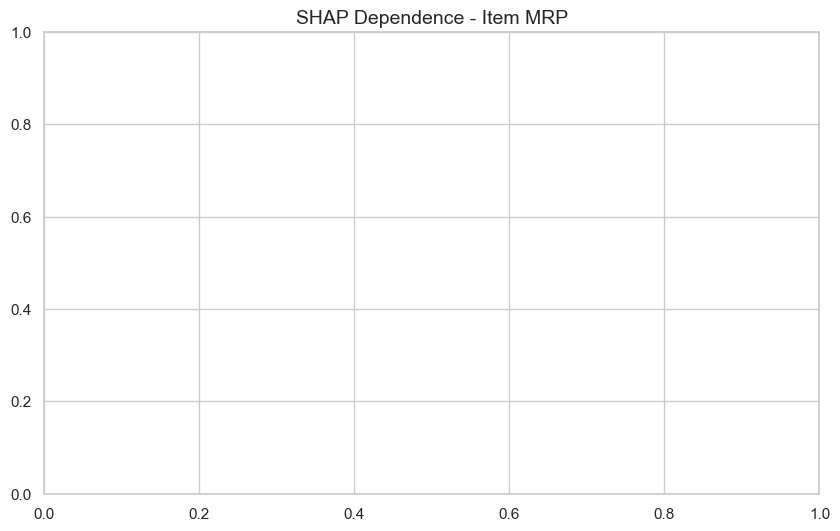

In [232]:
shap.plots.scatter(
    shap_values[:, "Item_MRP"],
    color=shap_values
)

plt.title(
    "SHAP Dependence - Item MRP"
)

plt.show()

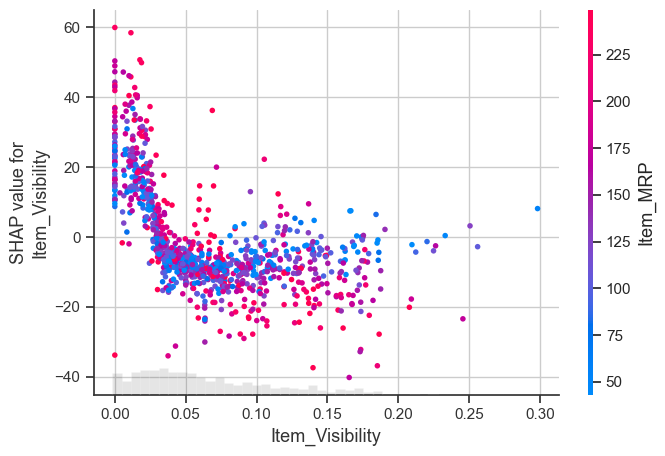

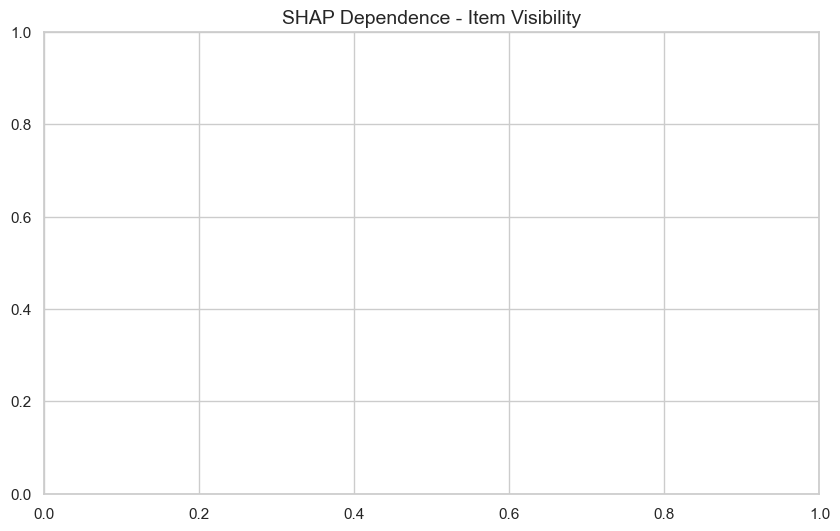

In [233]:
shap.plots.scatter(
    shap_values[:, "Item_Visibility"],
    color=shap_values
)

plt.title(
    "SHAP Dependence - Item Visibility"
)

plt.show()

In [234]:
row_index = 0

single_row = X_holdout_cb.iloc[
    [row_index]
]

actual_value = y_holdout.iloc[
    row_index
]

predicted_value = final_baseline_catboost.predict(
    single_row
)[0]

print("Actual Sales   :", round(actual_value, 2))
print("Predicted Sales:", round(predicted_value, 2))

Actual Sales   : 1743.06
Predicted Sales: 1238.21


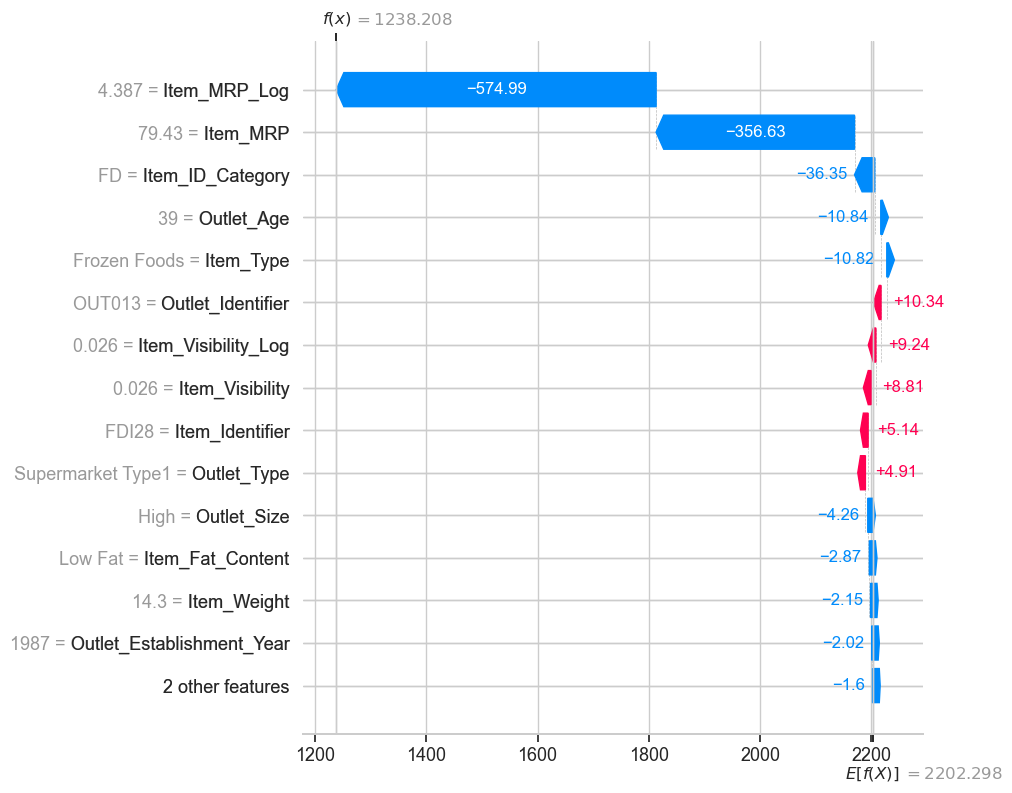

In [235]:
single_shap = explainer(
    single_row
)

shap.plots.waterfall(
    single_shap[0],
    max_display=15
)

In [236]:
def explain_prediction(
    model,
    explainer,
    row
):
    """
    Generate a prediction and SHAP explanation
    for a single observation.
    """

    prediction = model.predict(row)[0]

    shap_result = explainer(row)

    return prediction, shap_result

In [237]:
prediction, explanation = explain_prediction(
    final_baseline_catboost,
    explainer,
    single_row
)

print(
    "Predicted Sales:",
    round(prediction, 2)
)

Predicted Sales: 1238.21


In [238]:
shap_row = explanation[0]

feature_names = X_shap.columns

contributions = pd.DataFrame({
    "Feature": feature_names,
    "SHAP_Value": shap_row.values
})

contributions["Abs_SHAP"] = (
    contributions["SHAP_Value"]
    .abs()
)

contributions = (
    contributions
    .sort_values(
        "Abs_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

contributions.head(10)

,Feature,SHAP_Value,Abs_SHAP
0,Item_MRP_Log,-574.993291,574.993291
1,Item_MRP,-356.633884,356.633884
2,Item_ID_Category,-36.345002,36.345002
3,Outlet_Age,-10.844226,10.844226
4,Item_Type,-10.823146,10.823146
5,Outlet_Identifier,10.341340,10.341340
6,Item_Visibility_Log,9.244141,9.244141
7,Item_Visibility,8.808437,8.808437
8,Item_Identifier,5.143063,5.143063
9,Outlet_Type,4.911646,4.911646


In [239]:
positive_contributors = (
    contributions[
        contributions["SHAP_Value"] > 0
    ]
    .head(5)
)

negative_contributors = (
    contributions[
        contributions["SHAP_Value"] < 0
    ]
    .head(5)
)

print("Top positive contributors:")
display(positive_contributors)

print("\nTop negative contributors:")
display(negative_contributors)

Top positive contributors:


,Feature,SHAP_Value,Abs_SHAP
5,Outlet_Identifier,10.341340,10.341340
6,Item_Visibility_Log,9.244141,9.244141
7,Item_Visibility,8.808437,8.808437
8,Item_Identifier,5.143063,5.143063
9,Outlet_Type,4.911646,4.911646



Top negative contributors:


,Feature,SHAP_Value,Abs_SHAP
0,Item_MRP_Log,-574.993291,574.993291
1,Item_MRP,-356.633884,356.633884
2,Item_ID_Category,-36.345002,36.345002
3,Outlet_Age,-10.844226,10.844226
4,Item_Type,-10.823146,10.823146


In [240]:
shap_importance_report = contributions[
    [
        "Feature",
        "SHAP_Value",
        "Abs_SHAP"
    ]
]

shap_importance_report.to_csv(
    "../reports/shap_feature_importance.csv",
    index=False
)

print(
    "SHAP importance report saved."
)

SHAP importance report saved.


# 🚀 Final Production Model

After completing model comparison, feature experiments, cross-validation,
hyperparameter optimization, ensemble testing, stacking, and explainability,
CatBoost was selected as the final individual model.

The production model is now retrained using the complete labeled training
dataset so that all available training information can be utilized.

The model will then be saved for inference and deployment.

In [241]:
# Start again from the original cleaned training data
X_production = train_final.drop(
    columns=[TARGET]
).copy()

y_production = train_final[TARGET].copy()

# Apply the selected final feature engineering
X_production = final_feature_engineering(
    X_production
)

print("Production features:", X_production.shape)
print("Production target  :", y_production.shape)

Production features: (8523, 16)
Production target  : (8523,)


In [242]:
X_production_test = final_feature_engineering(
    test_final.copy()
)

print("Production test features:", X_production_test.shape)

Production test features: (5681, 16)


In [243]:
production_cat_features = (
    X_production
    .select_dtypes(include=["object"])
    .columns
    .tolist()
)

print("Categorical features:")
print(production_cat_features)

Categorical features:
['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Outlet_Identifier', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type', 'Item_ID_Category']


In [244]:
X_production_cb = X_production.copy()
X_production_test_cb = X_production_test.copy()

for col in production_cat_features:

    X_production_cb[col] = (
        X_production_cb[col]
        .astype(str)
    )

    X_production_test_cb[col] = (
        X_production_test_cb[col]
        .astype(str)
    )

print("Production data prepared for CatBoost.")

Production data prepared for CatBoost.


In [245]:
final_production_model = CatBoostRegressor(
    iterations=800,
    learning_rate=0.03,
    depth=6,
    l2_leaf_reg=5,
    loss_function="RMSE",
    random_seed=SEED,
    thread_count=1,
    verbose=False
)

final_production_model.fit(
    X_production_cb,
    y_production,
    cat_features=production_cat_features
)

print("Final production model trained.")

Final production model trained.


In [246]:
production_model_path = (
    "../models/"
    "bigmart_catboost_final.cbm"
)

final_production_model.save_model(
    production_model_path
)

print(
    "Model saved to:",
    production_model_path
)

Model saved to: ../models/bigmart_catboost_final.cbm


In [247]:
import json

model_metadata = {
    "model_name": "BigMart CatBoost Sales Predictor",
    "algorithm": "CatBoostRegressor",
    "target": TARGET,
    "random_seed": SEED,
    "iterations": 800,
    "learning_rate": 0.03,
    "depth": 6,
    "l2_leaf_reg": 5,
    "validation_r2": round(
        final_baseline_metrics["R2"],
        6
    ),
    "validation_mae": round(
        final_baseline_metrics["MAE"],
        6
    ),
    "validation_rmse": round(
        final_baseline_metrics["RMSE"],
        6
    ),
    "categorical_features": production_cat_features,
    "feature_count": X_production_cb.shape[1]
}

metadata_path = (
    "../models/"
    "bigmart_model_metadata.json"
)

with open(
    metadata_path,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        model_metadata,
        f,
        indent=4
    )

print("Metadata saved to:", metadata_path)

Metadata saved to: ../models/bigmart_model_metadata.json


In [248]:
def prepare_prediction_input(input_df):
    """
    Prepare raw BigMart input data for the production model.
    """

    df = input_df.copy()

    # Standardize categorical values
    df = clean_categorical_values(df)

    # Feature engineering
    df = final_feature_engineering(df)

    # Convert categorical columns
    for col in production_cat_features:

        if col in df.columns:
            df[col] = (
                df[col]
                .astype(str)
            )

    return df

In [249]:
def predict_sales(input_df):
    """
    Predict Item_Outlet_Sales for one or more observations.
    """

    prepared_data = prepare_prediction_input(
        input_df
    )

    predictions = final_production_model.predict(
        prepared_data
    )

    return np.asarray(predictions)

In [250]:
sample_input = test_final.iloc[[0]].copy()

sample_prediction = predict_sales(
    sample_input
)

print(
    "Predicted Item Outlet Sales:",
    round(float(sample_prediction[0]), 2)
)

Predicted Item Outlet Sales: 1853.41


In [251]:
sample_batch = test_final.head(10).copy()

batch_predictions = predict_sales(
    sample_batch
)

prediction_preview = sample_batch[
    [
        "Item_Identifier",
        "Item_MRP",
        "Outlet_Identifier",
        "Outlet_Type"
    ]
].copy()

prediction_preview[
    "Predicted_Item_Outlet_Sales"
] = batch_predictions

prediction_preview

,Item_Identifier,Item_MRP,Outlet_Identifier,Outlet_Type,Predicted_Item_Outlet_Sales
0,FDW58,107.8622,OUT049,Supermarket Type1,1853.408488
1,FDW14,87.3198,OUT017,Supermarket Type1,1397.609924
2,NCN55,241.7538,OUT010,Grocery Store,643.405451
3,FDQ58,155.0340,OUT017,Supermarket Type1,2534.320087
4,FDY38,234.2300,OUT027,Supermarket Type3,5962.406584
5,FDH56,117.1492,OUT046,Supermarket Type1,1919.554801
6,FDL48,50.1034,OUT018,Supermarket Type2,603.678033
7,FDC48,81.0592,OUT027,Supermarket Type3,2109.531810
8,FDN33,95.7436,OUT045,Supermarket Type1,1474.763472
9,FDA36,186.8924,OUT017,Supermarket Type1,3249.693466


In [252]:
test_predictions = predict_sales(
    test_final
)

submission = test_final.copy()

submission[
    "Item_Outlet_Sales_Predicted"
] = test_predictions

print(
    "Prediction rows:",
    len(submission)
)

submission.head()

Prediction rows: 5681


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales_Predicted
0,FDW58,20.750,Low Fat,0.007565,Snack Foods,107.8622,OUT049,1999,Medium,Tier 1,Supermarket Type1,1853.408488
1,FDW14,8.300,Regular,0.038428,Dairy,87.3198,OUT017,2007,NaN,Tier 2,Supermarket Type1,1397.609924
2,NCN55,14.600,Low Fat,0.099575,Others,241.7538,OUT010,1998,NaN,Tier 3,Grocery Store,643.405451
3,FDQ58,7.315,Low Fat,0.015388,Snack Foods,155.0340,OUT017,2007,NaN,Tier 2,Supermarket Type1,2534.320087
4,FDY38,NaN,Regular,0.118599,Dairy,234.2300,OUT027,1985,Medium,Tier 3,Supermarket Type3,5962.406584


In [253]:
prediction_path = (
    "../reports/"
    "BigMart_Test_Predictions.csv"
)

submission.to_csv(
    prediction_path,
    index=False
)

print(
    "Predictions saved to:",
    prediction_path
)

Predictions saved to: ../reports/BigMart_Test_Predictions.csv


In [254]:
feature_metadata = {
    "features": X_production_cb.columns.tolist(),
    "categorical_features": production_cat_features,
    "target": TARGET
}

feature_metadata_path = (
    "../models/"
    "bigmart_feature_metadata.json"
)

with open(
    feature_metadata_path,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        feature_metadata,
        f,
        indent=4
    )

print(
    "Feature metadata saved."
)

Feature metadata saved.


In [255]:
loaded_model = CatBoostRegressor()

loaded_model.load_model(
    "../models/bigmart_catboost_final.cbm"
)

print("Saved model loaded successfully.")

Saved model loaded successfully.


In [256]:
loaded_prediction = loaded_model.predict(
    sample_input_prepared
) if False else None

In [257]:
sample_prepared = prepare_prediction_input(
    sample_input
)

loaded_prediction = loaded_model.predict(
    sample_prepared
)

print(
    "Reloaded model prediction:",
    round(float(loaded_prediction[0]), 2)
)

Reloaded model prediction: 1853.41


In [258]:
print(
    "Original model prediction:",
    round(float(sample_prediction[0]), 2)
)

print(
    "Reloaded model prediction:",
    round(float(loaded_prediction[0]), 2)
)

Original model prediction: 1853.41
Reloaded model prediction: 1853.41


In [260]:
import sys

sys.path.append("../src")

from prediction_pipeline import predict_sales

In [261]:
test_sample = test_final.iloc[[0]].copy()

production_prediction = predict_sales(
    test_sample
)

print(
    "Production module prediction:",
    round(
        float(production_prediction[0]),
        2
    )
)

Production module prediction: 1853.41


In [262]:
print(
    "Notebook prediction:",
    round(
        float(sample_prediction[0]),
        2
    )
)

print(
    "Production prediction:",
    round(
        float(production_prediction[0]),
        2
    )
)

Notebook prediction: 1853.41
Production prediction: 1853.41


In [263]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.


In [265]:
import sys

if "../src" not in sys.path:
    sys.path.insert(0, "../src")

from prediction_pipeline import predict_sales

test_sample = test_final.iloc[[0]].copy()

prediction = predict_sales(
    test_sample
)

print(
    "Prediction:",
    round(float(prediction[0]), 2)
)

Prediction: 1853.41


In [1]:
from pathlib import Path

project = Path(r"C:\Users\nikit\BigMart_Sales_ML")

print("Project folder:", project)
print("\n.gitignore exists:", (project / ".gitignore").exists())
print(".dockerignore exists:", (project / ".dockerignore").exists())

print("\nProject files:")
for item in sorted(project.iterdir()):
    print(" -", item.name)

Project folder: C:\Users\nikit\BigMart_Sales_ML

.gitignore exists: True
.dockerignore exists: True

Project files:
 - .dockerignore
 - .gitignore
 - .ipynb_checkpoints
 - anaconda_projects
 - api
 - app
 - data
 - data_external
 - docker-compose.yml
 - Dockerfile.api
 - Dockerfile.streamlit
 - models
 - notebooks
 - reports
 - requirements.txt
 - src
 - Untitled.ipynb
